# Phase 1 — Exposure Landscape
This notebook implements the Phase‑1 exposure analysis (occupation + industry), using `srvy_wght_tru2` as the primary weight. All outputs are exported under `Results Datasets/analysis/phase1/`.

## 0) Setup

In [9]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Paths
def find_root():
    if "__file__" in globals():
        return Path(__file__).resolve().parents[2]
    cwd = Path.cwd().resolve()
    for p in [cwd] + list(cwd.parents):
        if (p / "Results Datasets" / "final_analysis_dataset.parquet").exists():
            return p
    return cwd
ROOT = find_root()
DATA_PATH = ROOT / "Results Datasets" / "final_analysis_dataset.parquet"
OUT_ROOT = ROOT / "Results Datasets" / "analysis" / "phase1"
OUT_TABLES = OUT_ROOT / "tables"
OUT_VIS = OUT_ROOT / "visuals"
for d in [OUT_ROOT, OUT_TABLES, OUT_VIS]:
    d.mkdir(parents=True, exist_ok=True)

# --- Load data
if not DATA_PATH.exists():
    raise FileNotFoundError(DATA_PATH)

cols = None  # load all
_df = pd.read_parquet(DATA_PATH)
# Year filter
_df = _df[(_df["adve_time_year"] >= 2010) & (_df["adve_time_year"] <= 2024)].copy()

# Core columns
occ_exp_col = "occupation_exposure"
ind_exp_col = "industry_exposure_weighted"
occ_raw_col = "occu_isco_2008"  # raw ISCO
noga_col = "comp_indu_noga"

# Ensure numeric exposure
for col in [occ_exp_col, ind_exp_col]:
    _df[col] = pd.to_numeric(_df[col], errors="coerce")

# --- Labels (cross‑walks)
def weighted_quantile(values, weights, q):
    vals = values.to_numpy(dtype=float)
    wts = weights.to_numpy(dtype=float)
    mask = ~np.isnan(vals) & ~np.isnan(wts)
    if mask.sum() == 0:
        return np.nan
    vals = vals[mask]
    wts = wts[mask]
    order = np.argsort(vals)
    vals = vals[order]
    wts = wts[order]
    cum = np.cumsum(wts)
    total = cum[-1]
    return vals[np.searchsorted(cum, q * total)]

CW_DIR = ROOT / "External datasets" / "Cross-walks"

# NOGA labels
noga_map = {}
path_noga = CW_DIR / "comp_indu_noga_to_noga2digit_expanded.csv"
if path_noga.exists():
    noga = pd.read_csv(path_noga)
    noga["comp_indu_noga"] = pd.to_numeric(noga["comp_indu_noga"], errors="coerce")
    noga_map = (
        noga.dropna(subset=["comp_indu_noga"])
        .drop_duplicates(subset=["comp_indu_noga"])
        .set_index("comp_indu_noga")["label_de"].to_dict()
    )

# ISCO labels
isco1_map = {}
isco2_map = {}
path_isco1 = CW_DIR / "isco_major_code_to_label.csv"
path_isco2 = CW_DIR / "isco_08_submajor_2digit_code_to_label.csv"
if path_isco1.exists():
    t = pd.read_csv(path_isco1)
    t["isco_major"] = pd.to_numeric(t["isco_major"], errors="coerce")
    isco1_map = t.set_index("isco_major")["label_en"].to_dict()
if path_isco2.exists():
    t = pd.read_csv(path_isco2)
    t["isco_08_submajor_2d"] = pd.to_numeric(t["isco_08_submajor_2d"], errors="coerce")
    isco2_map = t.set_index("isco_08_submajor_2d")["label_en"].to_dict()

# Build raw ISCO string
isco_raw_str = _df[occ_raw_col].astype("string").str.split(".").str[0]
isco_raw_str = isco_raw_str.str.replace(r"[^0-9]", "", regex=True)
# zero-fill to 4 digits if numeric and length < 4
isco_raw_str = isco_raw_str.apply(lambda x: x.zfill(4) if x is not pd.NA and str(x).isdigit() and len(str(x)) < 4 else x)

major_placeholders = {"1000","2000","3000","4000","5000","6000","7000","8000","9000"}
isco_is_major_placeholder = isco_raw_str.isin(major_placeholders)

# Labels (do not add permanent new code columns to dataset; just build series)
isco1_label = isco_raw_str.str[:1].apply(lambda x: isco1_map.get(int(x)) if str(x).isdigit() else pd.NA)
isco2_label = isco_raw_str.apply(
    lambda x: "Unknown sub-major (major group only)" if x in major_placeholders else (
        isco2_map.get(int(str(x)[:2])) if str(x)[:2].isdigit() else pd.NA
    )
)

if "comp_indu_noga_label" in _df.columns and _df["comp_indu_noga_label"].notna().any():
    _df["comp_indu_noga_label"] = _df["comp_indu_noga_label"].astype("string")
elif noga_map:
    _df["comp_indu_noga_label"] = pd.to_numeric(_df[noga_col], errors="coerce").map(noga_map).astype("string")
else:
    _df["comp_indu_noga_label"] = pd.NA
_df["occu_isco1_label"] = isco1_label.astype("string")
_df["occu_isco2_label"] = isco2_label.astype("string")
_df["isco_is_major_placeholder"] = isco_is_major_placeholder

# Diagnostic table for placeholders
placeholder_counts = (
    pd.DataFrame({"isco_raw": isco_raw_str, "is_placeholder": isco_is_major_placeholder})
    .loc[isco_is_major_placeholder, "isco_raw"]
    .value_counts()
    .rename_axis("isco_raw")
    .reset_index(name="count")
)
placeholder_diag = pd.DataFrame({
    "total_rows": [len(_df)],
    "placeholder_rows": [isco_is_major_placeholder.sum()],
    "placeholder_share": [isco_is_major_placeholder.mean()],
})
placeholder_diag.to_csv(OUT_TABLES / "table_isco_placeholder_diagnostic.csv", index=False)

# Region labels (Unknown kept)
special_codes = {"-3","-7","-8","-9"}

canton_map = {
    1:"ZH",2:"BE",3:"LU",4:"UR",5:"SZ",6:"OW",7:"NW",8:"GL",9:"ZG",
    10:"FR",11:"SO",12:"BS",13:"BL",14:"SH",15:"AR",16:"AI",17:"SG",
    18:"GR",19:"AG",20:"TG",21:"TI",22:"VD",23:"VS",24:"NE",25:"GE",26:"JU"
}

def label_region(series, is_canton=False):
    raw = series.astype("string")
    lab = raw.where(~raw.isin(special_codes), other="Unknown")
    lab = lab.fillna("Unknown")
    if is_canton:
        def map_canton(val):
            if val == "Unknown" or pd.isna(val):
                return "Unknown"
            return canton_map.get(int(val), val) if str(val).isdigit() else val
        lab = lab.apply(map_canton)
    return lab.astype("string")

_df["loca_regi_kant_label"] = label_region(_df["loca_regi_kant"], is_canton=True)
_df["loca_regi_nuts_label"] = label_region(_df["loca_regi_nuts"], is_canton=False)

# Merge Ostschweiz + Ticino for NUTS-2 labels
def _merge_nuts_label(series):
    return series.apply(lambda x: 'Ostschweiz and Ticino' if isinstance(x, str) and ('Ostschweiz' in x or 'Ticino' in x) else x)

if 'loca_regi_nuts_label' in _df.columns:
    _df['loca_regi_nuts_label'] = _merge_nuts_label(_df['loca_regi_nuts_label'])


# Thresholds (global, unweighted)
# Unweighted thresholds (reference only)
occ_p80_unw, occ_p90_unw = _df[occ_exp_col].quantile([0.8,0.9]).values
ind_p80_unw, ind_p90_unw = _df[ind_exp_col].quantile([0.8,0.9]).values
# Weighted thresholds (tru2) used in all analysis
occ_p80 = weighted_quantile(_df[occ_exp_col], _df["srvy_wght_tru2"], 0.80)
occ_p90 = weighted_quantile(_df[occ_exp_col], _df["srvy_wght_tru2"], 0.90)
ind_p80 = weighted_quantile(_df[ind_exp_col], _df["srvy_wght_tru2"], 0.80)
ind_p90 = weighted_quantile(_df[ind_exp_col], _df["srvy_wght_tru2"], 0.90)
occ_p20 = weighted_quantile(_df[occ_exp_col], _df["srvy_wght_tru2"], 0.20)
occ_p40 = weighted_quantile(_df[occ_exp_col], _df["srvy_wght_tru2"], 0.40)
occ_p60 = weighted_quantile(_df[occ_exp_col], _df["srvy_wght_tru2"], 0.60)
ind_p20 = weighted_quantile(_df[ind_exp_col], _df["srvy_wght_tru2"], 0.20)
ind_p40 = weighted_quantile(_df[ind_exp_col], _df["srvy_wght_tru2"], 0.40)
ind_p60 = weighted_quantile(_df[ind_exp_col], _df["srvy_wght_tru2"], 0.60)

# Coverage (tru2-weighted)
tru2_total = _df["srvy_wght_tru2"].sum()
occ_cov_tru2 = _df.loc[_df[occ_exp_col].notna(), "srvy_wght_tru2"].sum() / tru2_total
ind_cov_tru2 = _df.loc[_df[ind_exp_col].notna(), "srvy_wght_tru2"].sum() / tru2_total

# Unknown region share (tru2)
unknown_kant_share = _df.loc[_df["loca_regi_kant_label"] == "Unknown", "srvy_wght_tru2"].sum() / tru2_total
unknown_nuts_share = _df.loc[_df["loca_regi_nuts_label"] == "Unknown", "srvy_wght_tru2"].sum() / tru2_total

summary = {
    "thresholds": {
        "occ_p80": float(occ_p80), "occ_p90": float(occ_p90),
        "ind_p80": float(ind_p80), "ind_p90": float(ind_p90),
    },
    "coverage_tru2": {"occ": float(occ_cov_tru2), "ind": float(ind_cov_tru2)},
    "unknown_region_share_tru2": {"kanton": float(unknown_kant_share), "nuts": float(unknown_nuts_share)},
    "scatter_label_strategy": "labels = top 10 by demand + top 10 by mean exposure + top 10 by exposed demand (+ optional lowest exposure); deduplicated",
}

(OUT_ROOT / "phase1_summary.json").write_text(json.dumps(summary, indent=2))
summary

# Helper: drop non-finite values before plotting
def _finite_for_plot(df, x_col, y_col, y_positive=False):
    tmp = df.replace([np.inf, -np.inf], np.nan)
    tmp = tmp[tmp[x_col].notna() & tmp[y_col].notna()]
    if y_positive:
        tmp = tmp[tmp[y_col] > 0]
    return tmp



In [10]:
# Ensure color maps exist (in case cells run out of order)
# Ensure label helper functions exist even if color maps already built
if '_base_label' not in globals():
    def _base_label(label):
        s = str(label)
        if ' (exp=' in s:
            s = s.split(' (exp=')[0]
        return s
if '_normalize_other' not in globals():
    def _normalize_other(label, other_label="Other"):
        s = _base_label(label)
        if s.lower().startswith('other'):
            return other_label
        return s
if "build_color_map" not in globals():
    from matplotlib import cm
    def _base_label(label):
        s = str(label)
        # strip exposure suffix if present
        if ' (exp=' in s:
            s = s.split(' (exp=')[0]
        return s

def build_color_map(labels, other_label="Other"):
    # stable ordering as provided
    base = list(cm.get_cmap("tab20").colors) + list(cm.get_cmap("tab20b").colors) + list(cm.get_cmap("tab20c").colors)
    # mute/blend toward white
    def mute(rgb, alpha=0.7):
        r, g, b = rgb[:3]
        return (alpha*r + (1-alpha)*1.0, alpha*g + (1-alpha)*1.0, alpha*b + (1-alpha)*1.0, 1.0)
    muted = [mute(c) for c in base]

    cmap = {}
    i = 0
    for lab in labels:
        lab_norm = _normalize_other(lab, other_label=other_label)
        if lab_norm == other_label:
            continue
        if lab_norm in cmap:
            continue
        cmap[lab_norm] = muted[i % len(muted)]
        i += 1
    cmap[other_label] = (0.85, 0.85, 0.85, 1.0)
    return cmap

def color_for_label(label, cmap, other_label="Other"):
    key = _normalize_other(label, other_label=other_label)
    return cmap.get(key, (0.85,0.85,0.85,1.0))

# Build global label orders by national tru2-weighted share

# Normalize label orders (preserve importance order)
def _ordered_labels_from_series(s):
    seen = set()
    out = []
    for lab in s.index:
        lab_norm = _normalize_other(lab)
        if lab_norm in seen:
            continue
        seen.add(lab_norm)
        out.append(lab_norm)
    return out


# NOGA section
if 'noga_section_label' in _df.columns:
    _noga_label_col = 'noga_section_label'
elif 'industry_section_label' in _df.columns:
    _noga_label_col = 'industry_section_label'
else:
    _noga_label_col = None

if _noga_label_col:
    noga_section_order = (
        _df.groupby(_df[_noga_label_col].fillna('Unknown'))['srvy_wght_tru2']
           .sum().sort_values(ascending=False)
    )
else:
    noga_section_order = pd.Series([], dtype=float)
# comp_indu_noga
comp_noga_order = (
    _df.groupby(_df['comp_indu_noga_label'].fillna('Unknown'))['srvy_wght_tru2']
       .sum().sort_values(ascending=False)
)

# ISCO-1
isco1_order = (
    _df.groupby(_df['occu_isco1_label'].fillna('Unknown'))['srvy_wght_tru2']
       .sum().sort_values(ascending=False)
)

# ISCO-2
isco2_order = (
    _df.groupby(_df['occu_isco2_label'].fillna('Unknown'))['srvy_wght_tru2']
       .sum().sort_values(ascending=False)
)

# ISCO-4 (use code label in occ4_label)
if 'occ4_label' in _df.columns:
    isco4_order = (
        _df.groupby(_df['occ4_label'].fillna('Unknown'))['srvy_wght_tru2']
           .sum().sort_values(ascending=False)
    )
else:
    isco4_order = pd.Series([], dtype=float)

# Build color maps
color_map_noga_section = build_color_map(_ordered_labels_from_series(noga_section_order), other_label='Other')
color_map_comp_noga = build_color_map(_ordered_labels_from_series(comp_noga_order), other_label='Other')
color_map_isco1 = build_color_map(_ordered_labels_from_series(isco1_order), other_label='Other')
color_map_isco2 = build_color_map(_ordered_labels_from_series(isco2_order), other_label='Other')
color_map_isco4 = build_color_map(_ordered_labels_from_series(isco4_order), other_label='Other')


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/1883880778.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = list(cm.get_cmap("tab20").colors) + list(cm.get_cmap("tab20b").colors) + list(cm.get_cmap("tab20c").colors)


## 1) Exposure over time (annual + rolling + binned)

/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/470776467.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_stats)


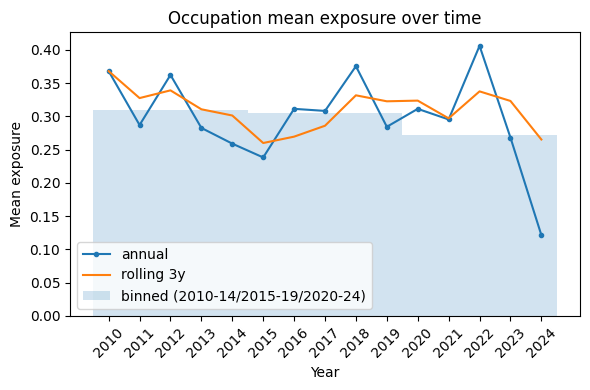

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_trend_occ_allviews.png


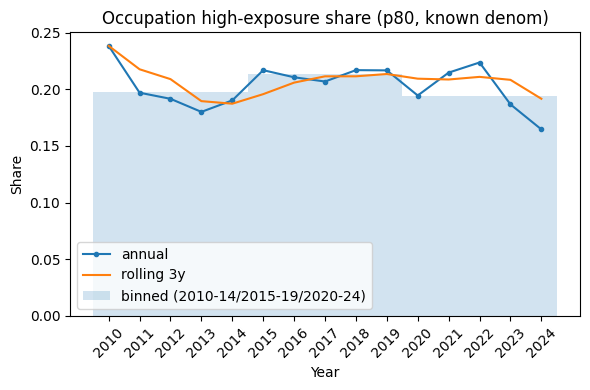

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_trend_occ_allviews_share.png


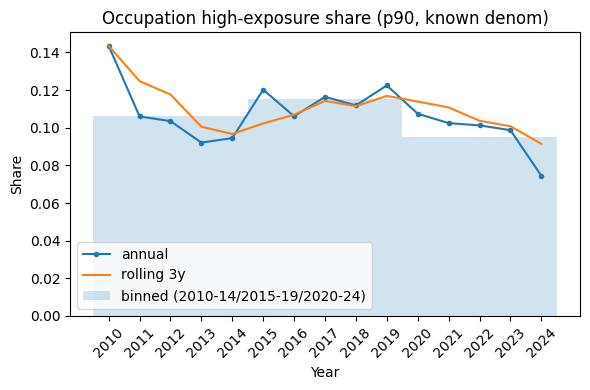

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_trend_occ_allviews_share_p90.png


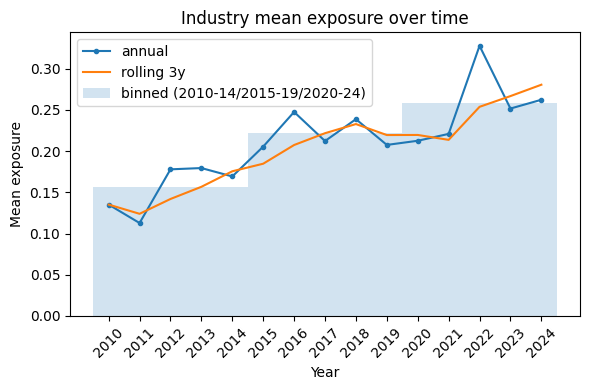

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_trend_ind_allviews.png


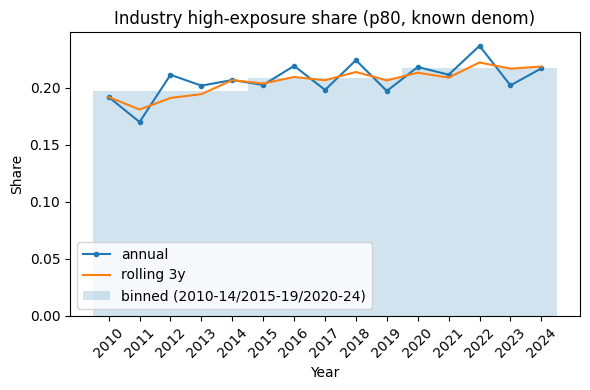

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_trend_ind_allviews_share.png


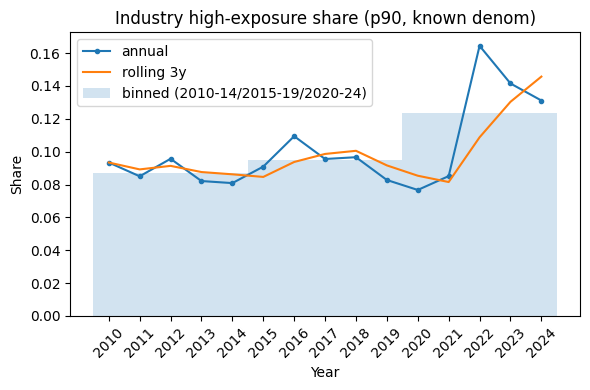

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_trend_ind_allviews_share_p90.png


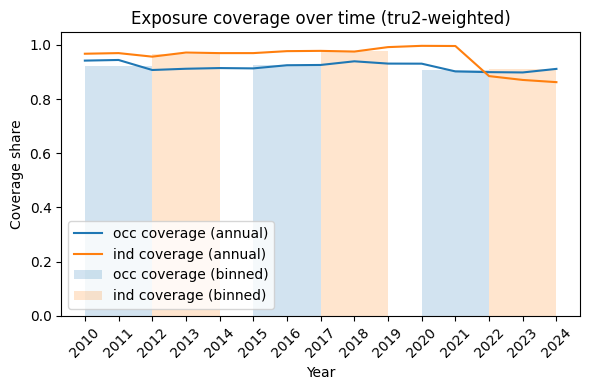

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_coverage_over_time.png


In [11]:
# Annual series

def compute_stats(g):
    tot_tru2 = g['srvy_wght_tru2'].sum()
    occ_known = g[occ_exp_col].notna()
    ind_known = g[ind_exp_col].notna()
    occ_denom = g.loc[occ_known, 'srvy_wght_tru2'].sum()
    ind_denom = g.loc[ind_known, 'srvy_wght_tru2'].sum()
    return pd.Series({
        'occ_mean_exp': np.average(g.loc[occ_known, occ_exp_col], weights=g.loc[occ_known, 'srvy_wght_tru2']) if occ_denom else np.nan,
        'ind_mean_exp': np.average(g.loc[ind_known, ind_exp_col], weights=g.loc[ind_known, 'srvy_wght_tru2']) if ind_denom else np.nan,
        'occ_high_share_p80': g.loc[occ_known & (g[occ_exp_col] >= occ_p80), 'srvy_wght_tru2'].sum() / occ_denom if occ_denom else np.nan,
        'occ_high_share_p90': g.loc[occ_known & (g[occ_exp_col] >= occ_p90), 'srvy_wght_tru2'].sum() / occ_denom if occ_denom else np.nan,
        'ind_high_share_p80': g.loc[ind_known & (g[ind_exp_col] >= ind_p80), 'srvy_wght_tru2'].sum() / ind_denom if ind_denom else np.nan,
        'ind_high_share_p90': g.loc[ind_known & (g[ind_exp_col] >= ind_p90), 'srvy_wght_tru2'].sum() / ind_denom if ind_denom else np.nan,
        'occ_coverage': occ_denom / tot_tru2 if tot_tru2 else np.nan,
        'ind_coverage': ind_denom / tot_tru2 if tot_tru2 else np.nan,
    })

trend_annual = (
    _df.groupby('adve_time_year')
    .apply(compute_stats)
    .reset_index()
    .rename(columns={'adve_time_year': 'year'})
    .sort_values('year')
)
trend_annual.to_csv(OUT_TABLES / "table_trends_annual.csv", index=False)

# Rolling 3y
trend_roll = trend_annual.set_index('year').rolling(window=3, min_periods=1).mean().reset_index()
trend_roll.to_csv(OUT_TABLES / "table_trends_rolling3y.csv", index=False)

# Binned (2010-2014, 2015-2019, 2020-2024)
_bins = [(2010, 2014), (2015, 2019), (2020, 2024)]
rows = []
for start, end in _bins:
    g = _df[(_df['adve_time_year'] >= start) & (_df['adve_time_year'] <= end)]
    if g.empty:
        continue
    row = compute_stats(g).to_dict()
    row['period'] = f"{start}-{end}"
    row['start'] = start
    row['end'] = end
    rows.append(row)
trend_binned = pd.DataFrame(rows)
trend_binned.to_csv(OUT_TABLES / "table_trends_binned3bins.csv", index=False)


def _plot_with_bins(col, title, ylabel, fig_name):
    plt.figure(figsize=(6,4))
    plt.plot(trend_annual['year'], trend_annual[col], label='annual', marker='o', ms=3)
    plt.plot(trend_roll['year'], trend_roll[col], label='rolling 3y')
    if not trend_binned.empty:
        mids = (trend_binned['start'] + trend_binned['end']) / 2
        widths = (trend_binned['end'] - trend_binned['start'] + 1)
        plt.bar(mids, trend_binned[col], width=widths, alpha=0.2,
                label='binned (2010-14/2015-19/2020-24)')
    plt.title(title)
    plt.xlabel('Year')
    plt.ylabel(ylabel)
    plt.legend()
    plt.xticks(trend_annual['year'], rotation=45)
    plt.tight_layout()
    fig_path = OUT_VIS / fig_name
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print('Saved', fig_path)

# Plots: occ
_plot_with_bins('occ_mean_exp', 'Occupation mean exposure over time', 'Mean exposure', 'fig_trend_occ_allviews.png')
_plot_with_bins('occ_high_share_p80', 'Occupation high-exposure share (p80, known denom)', 'Share', 'fig_trend_occ_allviews_share.png')
_plot_with_bins('occ_high_share_p90', 'Occupation high-exposure share (p90, known denom)', 'Share', 'fig_trend_occ_allviews_share_p90.png')

# Plots: ind
_plot_with_bins('ind_mean_exp', 'Industry mean exposure over time', 'Mean exposure', 'fig_trend_ind_allviews.png')
_plot_with_bins('ind_high_share_p80', 'Industry high-exposure share (p80, known denom)', 'Share', 'fig_trend_ind_allviews_share.png')
_plot_with_bins('ind_high_share_p90', 'Industry high-exposure share (p90, known denom)', 'Share', 'fig_trend_ind_allviews_share_p90.png')

# Coverage over time (lines + binned bars)
plt.figure(figsize=(6,4))
plt.plot(trend_annual['year'], trend_annual['occ_coverage'], label='occ coverage (annual)')
plt.plot(trend_annual['year'], trend_annual['ind_coverage'], label='ind coverage (annual)')
if not trend_binned.empty:
    mids = (trend_binned['start'] + trend_binned['end']) / 2
    widths = (trend_binned['end'] - trend_binned['start'] + 1)
    plt.bar(mids - widths*0.2, trend_binned['occ_coverage'], width=widths*0.4, alpha=0.2, label='occ coverage (binned)')
    plt.bar(mids + widths*0.2, trend_binned['ind_coverage'], width=widths*0.4, alpha=0.2, label='ind coverage (binned)')
plt.title('Exposure coverage over time (tru2-weighted)')
plt.xlabel('Year')
plt.ylabel('Coverage share')
plt.legend()
plt.xticks(trend_annual['year'], rotation=45)
plt.tight_layout()
fig_path = OUT_VIS / "fig_coverage_over_time.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print('Saved', fig_path)


## 2) Exposure distributions (CDFs)

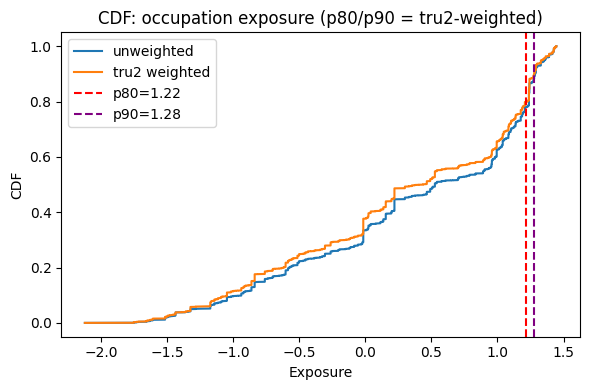

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_cdf_occ.png


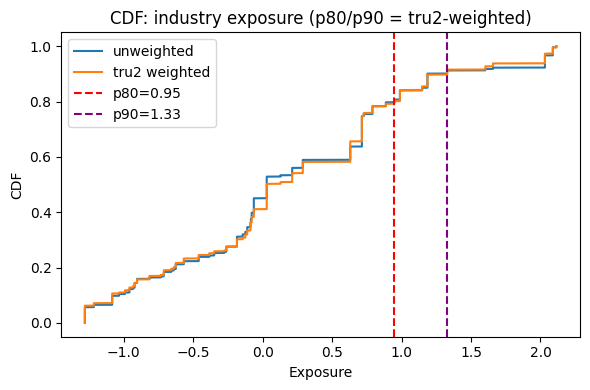

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_cdf_ind.png


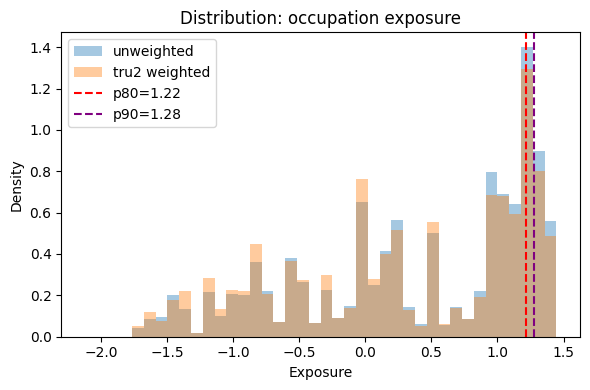

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_pdf_occ.png


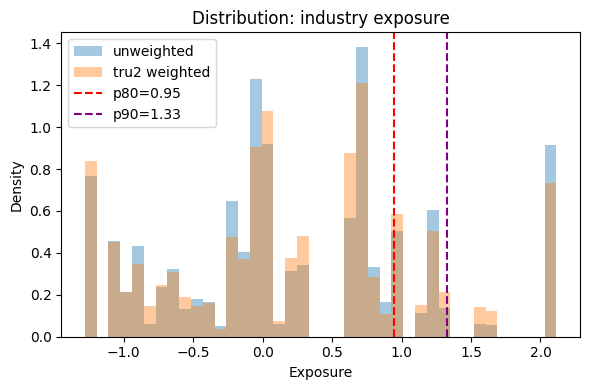

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_pdf_ind.png


In [12]:
def plot_cdf(series, weights=None, label="weighted", ax=None):
    s = series.dropna().to_numpy()
    if weights is None:
        w = np.ones_like(s)
    else:
        w = weights.loc[series.dropna().index].to_numpy()
    order = np.argsort(s)
    s_sorted = s[order]
    w_sorted = w[order]
    cum = np.cumsum(w_sorted)
    cum = cum / cum[-1]
    ax.plot(s_sorted, cum, label=label)

# Occupation CDF
fig, ax = plt.subplots(figsize=(6,4))
plot_cdf(_df[occ_exp_col], None, label="unweighted", ax=ax)
plot_cdf(_df[occ_exp_col], _df["srvy_wght_tru2"], label="tru2 weighted", ax=ax)
ax.axvline(occ_p80, color='red', linestyle='--', label=f'p80={occ_p80:.2f}')
ax.axvline(occ_p90, color='purple', linestyle='--', label=f'p90={occ_p90:.2f}')
ax.set_title("CDF: occupation exposure (p80/p90 = tru2‑weighted)")
ax.set_xlabel("Exposure")
ax.set_ylabel("CDF")
ax.legend()
plt.tight_layout()
fig_path = OUT_VIS / "fig_cdf_occ.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved", fig_path)

# Industry CDF
fig, ax = plt.subplots(figsize=(6,4))
plot_cdf(_df[ind_exp_col], None, label="unweighted", ax=ax)
plot_cdf(_df[ind_exp_col], _df["srvy_wght_tru2"], label="tru2 weighted", ax=ax)
ax.axvline(ind_p80, color='red', linestyle='--', label=f'p80={ind_p80:.2f}')
ax.axvline(ind_p90, color='purple', linestyle='--', label=f'p90={ind_p90:.2f}')
ax.set_title("CDF: industry exposure (p80/p90 = tru2‑weighted)")
ax.set_xlabel("Exposure")
ax.set_ylabel("CDF")
ax.legend()
plt.tight_layout()
fig_path = OUT_VIS / "fig_cdf_ind.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved", fig_path)


# Occupation distribution (non-cumulative)
fig, ax = plt.subplots(figsize=(6,4))
occ_s = _df[occ_exp_col].dropna()
occ_w = _df.loc[occ_s.index, "srvy_wght_tru2"]
bins = 40
ax.hist(occ_s, bins=bins, density=True, alpha=0.4, label="unweighted")
ax.hist(occ_s, bins=bins, density=True, weights=occ_w, alpha=0.4, label="tru2 weighted")
ax.axvline(occ_p80, color='red', linestyle='--', label=f'p80={occ_p80:.2f}')
ax.axvline(occ_p90, color='purple', linestyle='--', label=f'p90={occ_p90:.2f}')
ax.set_title("Distribution: occupation exposure")
ax.set_xlabel("Exposure")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
fig_path = OUT_VIS / "fig_pdf_occ.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved", fig_path)

# Industry distribution (non-cumulative)
fig, ax = plt.subplots(figsize=(6,4))
ind_s = _df[ind_exp_col].dropna()
ind_w = _df.loc[ind_s.index, "srvy_wght_tru2"]
ax.hist(ind_s, bins=bins, density=True, alpha=0.4, label="unweighted")
ax.hist(ind_s, bins=bins, density=True, weights=ind_w, alpha=0.4, label="tru2 weighted")
ax.axvline(ind_p80, color='red', linestyle='--', label=f'p80={ind_p80:.2f}')
ax.axvline(ind_p90, color='purple', linestyle='--', label=f'p90={ind_p90:.2f}')
ax.set_title("Distribution: industry exposure")
ax.set_xlabel("Exposure")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
fig_path = OUT_VIS / "fig_pdf_ind.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved", fig_path)


## 3) Concentration: Top‑X curve + summary

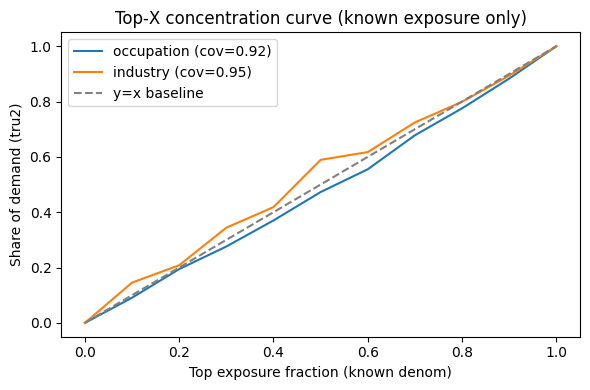

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_topx_known_denom.png


,top_fraction,occ_share,ind_share
0,0.0,0.000000,0.000000
1,0.1,0.090915,0.145514
2,0.2,0.194322,0.208364
3,0.3,0.276060,0.344134
4,0.4,0.370185,0.418411
5,0.5,0.472856,0.589156
6,0.6,0.555198,0.617293
7,0.7,0.678099,0.724606
8,0.8,0.775447,0.799009
9,0.9,0.883051,0.893890


In [27]:
def demand_share_at_threshold(col, thresh, weight_col):
    mask = _df[col].notna()
    denom = _df.loc[mask, weight_col].sum()
    if denom == 0:
        return np.nan
    return _df.loc[mask & (_df[col] >= thresh), weight_col].sum() / denom

rows = []
for col, label, p80, p90 in [
    (occ_exp_col, "occupation", occ_p80, occ_p90),
    (ind_exp_col, "industry", ind_p80, ind_p90),
]:
    p10 = weighted_quantile(_df[col], _df["srvy_wght_tru2"], 0.10)
    p50 = weighted_quantile(_df[col], _df["srvy_wght_tru2"], 0.50)
    row = {"measure": label}
    row["p80"] = p80
    row["p90"] = p90
    row["p10"] = p10
    row["p50"] = p50
    row["coverage_tru2"] = _df.loc[_df[col].notna(), "srvy_wght_tru2"].sum() / _df["srvy_wght_tru2"].sum()
    # tru2 (known-denom)
    row["share_top10_tru2"] = demand_share_at_threshold(col, p90, "srvy_wght_tru2")
    row["share_top20_tru2"] = demand_share_at_threshold(col, p80, "srvy_wght_tru2")
    row["share_top50_tru2"] = demand_share_at_threshold(col, p50, "srvy_wght_tru2")
    row["share_bottom10_tru2"] = _df.loc[_df[col].notna() & (_df[col] <= p10), "srvy_wght_tru2"].sum() / _df.loc[_df[col].notna(), "srvy_wght_tru2"].sum()
    # tru1 check (known-denom)
    row["share_top10_tru1"] = demand_share_at_threshold(col, p90, "srvy_wght_tru1")
    row["share_top20_tru1"] = demand_share_at_threshold(col, p80, "srvy_wght_tru1")
    row["share_top50_tru1"] = demand_share_at_threshold(col, p50, "srvy_wght_tru1")
    row["share_bottom10_tru1"] = _df.loc[_df[col].notna() & (_df[col] <= p10), "srvy_wght_tru1"].sum() / _df.loc[_df[col].notna(), "srvy_wght_tru1"].sum()
    rows.append(row)

concentration_tbl = pd.DataFrame(rows)
concentration_tbl.to_csv(OUT_TABLES / "table_concentration_summary.csv", index=False)
concentration_tbl

# Known-denom Top-X curve
occ_nonmiss = _df[_df[occ_exp_col].notna()].copy()
ind_nonmiss = _df[_df[ind_exp_col].notna()].copy()
occ_total = occ_nonmiss['srvy_wght_tru2'].sum()
ind_total = ind_nonmiss['srvy_wght_tru2'].sum()
xs = np.linspace(0, 1, 11)

def topx_share_nonmiss(sub_df, col, frac):
    if frac <= 0:
        return 0.0
    s = pd.to_numeric(sub_df[col], errors='coerce').to_numpy(dtype=float)
    w = sub_df['srvy_wght_tru2'].to_numpy(dtype=float)
    valid = ~np.isnan(s)
    s = s[valid]
    w = w[valid]
    if len(s) == 0:
        return np.nan
    cutoff = np.nanquantile(s, 1 - frac)
    mask = s >= cutoff
    return w[mask].sum() / w.sum()

rows = []
for x in xs:
    rows.append({
        'top_fraction': x,
        'occ_share': topx_share_nonmiss(occ_nonmiss, occ_exp_col, x),
        'ind_share': topx_share_nonmiss(ind_nonmiss, ind_exp_col, x),
    })
conc_curve = pd.DataFrame(rows)

cov_occ = occ_total / _df['srvy_wght_tru2'].sum()
cov_ind = ind_total / _df['srvy_wght_tru2'].sum()

plt.figure(figsize=(6,4))
plt.plot(conc_curve['top_fraction'], conc_curve['occ_share'], label=f'occupation (cov={cov_occ:.2f})')
plt.plot(conc_curve['top_fraction'], conc_curve['ind_share'], label=f'industry (cov={cov_ind:.2f})')
plt.plot(conc_curve['top_fraction'], conc_curve['top_fraction'], linestyle='--', color='gray', label='y=x baseline')
plt.xlabel('Top exposure fraction (known denom)')
plt.ylabel('Share of demand (tru2)')
plt.title('Top‑X concentration curve (known exposure only)')
plt.legend()
plt.tight_layout()
fig_path = OUT_VIS / "fig_topx_known_denom.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print('Saved', fig_path)
conc_curve


## 4) Exposure per code and correlatin with demand


### 4.1) Exposure per code and correlatin with demand  - Occupation

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/tables/table_occ1_full.csv


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/1124720179.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  occ1_metrics["mean_occ_exp_tru2"] = occ1_group.apply(lambda g: wmean(g, occ_exp_col)).values


,occ1_code,occ1_label,demand_total_tru2,postings_total_tru1,n_ads,mean_occ_exp_tru2
1,1,Managers,91537.2124,90578.3302,4097,1.027624
4,4,Clerical support workers,176291.7494,162884.8689,7209,0.992728
2,2,Professionals,488186.3847,466144.2435,18531,0.974903
3,3,Technicians and associate professionals,325930.3789,310510.4393,12114,0.446034
5,5,Service and sales workers,229944.986,200616.1767,7409,-0.334277
8,8,"Plant and machine operators, and assemblers",50935.7891,44847.0071,1791,-0.774513
7,7,Craft and related trades workers,227704.493,202966.9574,6963,-1.005614
6,6,"Skilled agricultural, forestry and fishery wor...",9622.3608,8791.2909,363,-1.101813
9,9,Elementary occupations,36799.1455,28909.682,1250,-1.374436
0,0,Armed forces occupations,1194.3476,1037.7297,67,NaN


Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/tables/table_occ2_full.csv


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/1124720179.py:84: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  occ2_metrics["mean_occ_exp_tru2"] = occ2_group.apply(lambda g: wmean(g, occ_exp_col)).values


,occ2_code,occ2_label,demand_total_tru2,postings_total_tru1,n_ads,mean_occ_exp_tru2
12,24,Business and administration professionals,94457.2123,90997.9087,3911,1.293706
5,12,Administrative and commercial managers,46026.6106,46044.4836,1830,1.253743
22,41,General and keyboard clerks,64141.7672,57852.5017,2535,1.221306
14,26,"Legal, social and cultural professionals",34916.8839,30927.6603,1409,1.207995
13,25,Information and communications technology prof...,114012.381,112983.8243,4066,1.194364
18,33,Business and administration associate professi...,98144.907,93285.477,4270,1.047808
9,21,Science and engineering professionals,96075.5559,94896.6775,3141,1.045777
4,11,"Chief executives, senior officials and legisla...",11207.6684,11158.4538,661,0.961023
24,43,Numerical and material recording clerks,45651.0499,42173.126,2000,0.923049
25,44,Other clerical support workers,44907.6461,43076.3148,1807,0.891291


Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/tables/table_occ4_top25_exposure.csv
Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/tables/table_occ4_bottom25_exposure.csv


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/1124720179.py:98: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  occ4_metrics["mean_occ_exp_tru2"] = occ4_group.apply(lambda g: wmean(g, occ_exp_col)).values


,occ4_code,occ4_label,demand_total_tru2,postings_total_tru1,n_ads,mean_occ_exp_tru2
9,1211,1211,3495.6574,3495.6574,140,1.446232
43,2120,2120,3302.2187,3202.8701,146,1.439613
116,2612,2612,1402.1959,1091.4363,26,1.435604
117,2619,2619,4634.5033,4554.424,226,1.431593
92,2411,2411,16992.3107,16307.398,627,1.426218
94,2413,2413,6043.9557,6010.6425,262,1.417316
124,2634,2634,4111.5871,3462.8513,158,1.416230
121,2631,2631,1587.9024,1319.5679,79,1.403764
93,2412,2412,12219.8399,10885.9884,498,1.390682
181,3312,3312,1261.5201,1261.5201,66,1.385560


,occ4_code,occ4_label,demand_total_tru2,postings_total_tru1,n_ads,mean_occ_exp_tru2
132,2653,2653,10.6667,5.3333,1,-2.122764
410,9121,9121,70.6236,70.6236,5,-1.950063
307,7121,7121,3643.987,3075.8136,71,-1.752941
421,9313,9313,2234.8459,1824.2314,79,-1.731342
417,9214,9214,1231.138,988.604,46,-1.712821
314,7131,7131,3779.6266,3049.0429,92,-1.657760
309,7123,7123,2286.9339,1798.4729,44,-1.648111
429,9412,9412,3177.6866,2612.3874,130,-1.630702
411,9122,9122,41.3889,41.3889,3,-1.629897
322,7214,7214,6395.2852,6647.1668,139,-1.609123


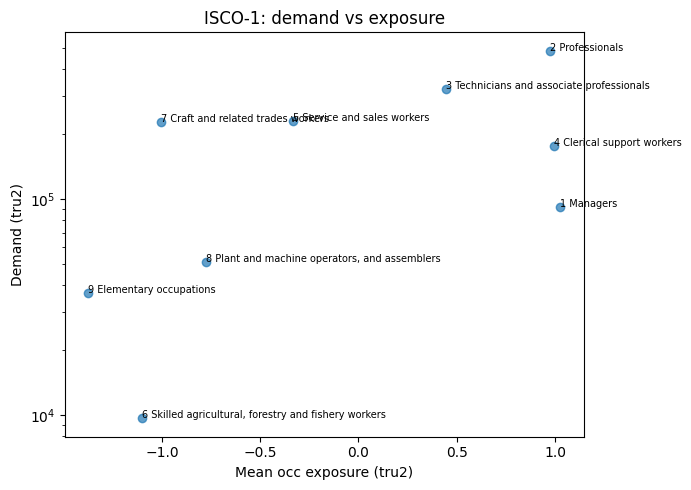

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_occ1_scatter.png
ISCO-1 Pearson: 0.5593074726592052
ISCO-1 Spearman: 0.5166666666666667
ISCO-1 Weighted Pearson: 0.5423773569109778


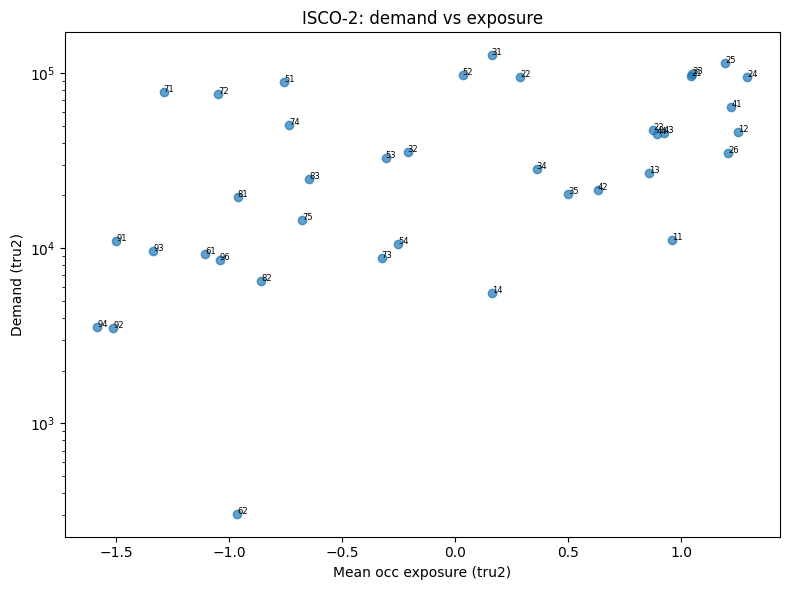

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_occ2_scatter_full.png
ISCO-2 Pearson: 0.43345623499297714
ISCO-2 Spearman: 0.5410876463508042
ISCO-2 Weighted Pearson: 0.22417575065587225


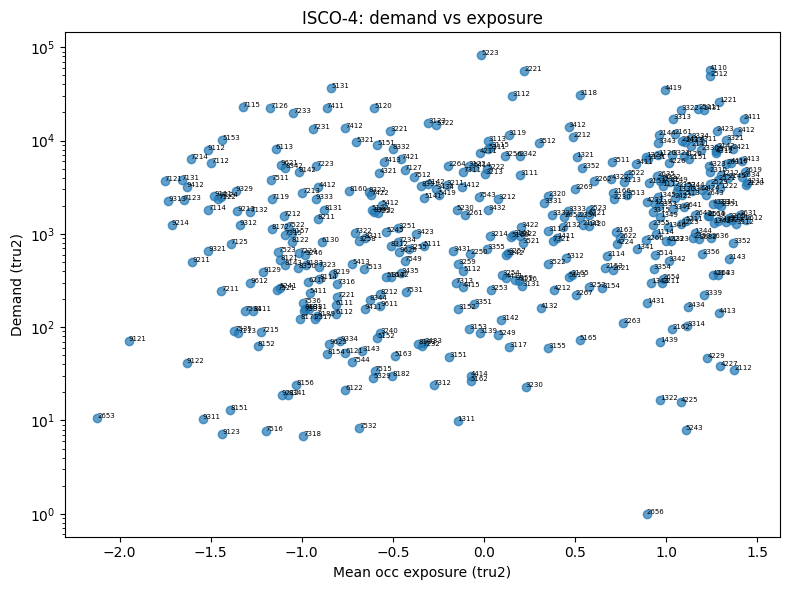

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_occ4_scatter_full.png


In [14]:
# Occupation impact lists (ISCO 1, 2, 4)

# Build codes/labels (in-memory)
_df["occ1_code"] = isco_raw_str.str[:1]
_df["occ1_label"] = _df["occu_isco1_label"].fillna("Unknown")
_df["occ2_code"] = isco_raw_str.str[:2]
_df["occ2_label"] = _df["occu_isco2_label"].fillna("Unknown")
_df["occ4_code"] = isco_raw_str
if "occu_isco4_label" in _df.columns:
    _df["occ4_label"] = _df["occu_isco4_label"].fillna(_df["occ4_code"])
else:
    _df["occ4_label"] = _df["occ4_code"]

# Weighted mean helper

def wmean(group, col):
    x = group[col]
    w = group["srvy_wght_tru2"]
    mask = x.notna()
    if mask.sum() == 0:
        return np.nan
    return np.average(x[mask], weights=w[mask])


# Correlation helper for scatter plots

def _to_1d(arr):
    if isinstance(arr, pd.DataFrame):
        arr = arr.iloc[:, 0]
    return pd.to_numeric(pd.Series(arr), errors="coerce").to_numpy()


def print_corr_metrics(label, df, x_col, y_col, w_col="demand_total_tru2"):
    # handle duplicate columns by picking first occurrence
    if isinstance(df, pd.DataFrame):
        df = df.loc[:, ~df.columns.duplicated()]
    use_cols = [x_col, y_col]
    if w_col in df.columns:
        use_cols.append(w_col)
    valid = df[use_cols].dropna()
    if valid.empty:
        print(f"{label}: no valid rows for correlation")
        return
    x = _to_1d(valid[x_col])
    y = _to_1d(valid[y_col])
    pearson = pd.Series(x).corr(pd.Series(y))
    spearman = pd.Series(x).corr(pd.Series(y), method="spearman")
    print(f"{label} Pearson:", pearson)
    print(f"{label} Spearman:", spearman)
    if w_col in valid.columns:
        w = _to_1d(valid[w_col])
        if w.sum() > 0:
            wmx = (x * w).sum() / w.sum()
            wmy = (y * w).sum() / w.sum()
            wcov = (w * (x - wmx) * (y - wmy)).sum() / w.sum()
            wsx = ((w * (x - wmx) ** 2).sum() / w.sum()) ** 0.5
            wsy = ((w * (y - wmy) ** 2).sum() / w.sum()) ** 0.5
            weighted = wcov / (wsx * wsy) if wsx > 0 and wsy > 0 else float('nan')
        else:
            weighted = float('nan')
        print(f"{label} Weighted Pearson:", weighted)

# ISCO-1 full list
occ1_group = _df.groupby(["occ1_code", "occ1_label"])
occ1_metrics = occ1_group.agg(
    demand_total_tru2=("srvy_wght_tru2", "sum"),
    postings_total_tru1=("srvy_wght_tru1", "sum"),
    n_ads=("srvy_wght_tru2", "size")
).reset_index()
occ1_metrics["mean_occ_exp_tru2"] = occ1_group.apply(lambda g: wmean(g, occ_exp_col)).values
occ1_metrics = occ1_metrics.sort_values("mean_occ_exp_tru2", ascending=False)
occ1_metrics.to_csv(OUT_TABLES / "table_occ1_full.csv", index=False)
print("Saved", OUT_TABLES / "table_occ1_full.csv")

display(occ1_metrics)

# ISCO-2 full list
occ2_group = _df.groupby(["occ2_code", "occ2_label"])
occ2_metrics = occ2_group.agg(
    demand_total_tru2=("srvy_wght_tru2", "sum"),
    postings_total_tru1=("srvy_wght_tru1", "sum"),
    n_ads=("srvy_wght_tru2", "size")
).reset_index()
occ2_metrics["mean_occ_exp_tru2"] = occ2_group.apply(lambda g: wmean(g, occ_exp_col)).values
occ2_metrics = occ2_metrics.sort_values("mean_occ_exp_tru2", ascending=False)
occ2_metrics.to_csv(OUT_TABLES / "table_occ2_full.csv", index=False)
print("Saved", OUT_TABLES / "table_occ2_full.csv")

display(occ2_metrics)

# ISCO-4 top/bottom 25 by exposure (with labels)
occ4_group = _df.groupby(["occ4_code", "occ4_label"])
occ4_metrics = occ4_group.agg(
    demand_total_tru2=("srvy_wght_tru2", "sum"),
    postings_total_tru1=("srvy_wght_tru1", "sum"),
    n_ads=("srvy_wght_tru2", "size")
).reset_index()
occ4_metrics["mean_occ_exp_tru2"] = occ4_group.apply(lambda g: wmean(g, occ_exp_col)).values

occ4_top25 = occ4_metrics.nlargest(25, "mean_occ_exp_tru2")
occ4_bottom25 = occ4_metrics.nsmallest(25, "mean_occ_exp_tru2")

occ4_top25.to_csv(OUT_TABLES / "table_occ4_top25_exposure.csv", index=False)
occ4_bottom25.to_csv(OUT_TABLES / "table_occ4_bottom25_exposure.csv", index=False)
print("Saved", OUT_TABLES / "table_occ4_top25_exposure.csv")
print("Saved", OUT_TABLES / "table_occ4_bottom25_exposure.csv")

display(occ4_top25)
display(occ4_bottom25)

# Scatter: ISCO-1 demand vs exposure
occ1_plot = _finite_for_plot(occ1_metrics, "mean_occ_exp_tru2", "demand_total_tru2", y_positive=True)
plt.figure(figsize=(7,5))
plt.scatter(occ1_plot["mean_occ_exp_tru2"], occ1_plot["demand_total_tru2"], alpha=0.7)
for _, row in occ1_plot.iterrows():
    label = f"{row['occ1_code']} {row['occ1_label']}"
    plt.text(row["mean_occ_exp_tru2"], row["demand_total_tru2"], label, fontsize=7)
plt.xlabel("Mean occ exposure (tru2)")
plt.ylabel("Demand (tru2)")
plt.yscale("log")
plt.title("ISCO‑1: demand vs exposure")
plt.tight_layout()
fig_path = OUT_VIS / "fig_occ1_scatter.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved", fig_path)
print_corr_metrics("ISCO-1", occ1_plot, "mean_occ_exp_tru2", "demand_total_tru2")

# Scatter: ISCO-2 demand vs exposure (IDs only)
occ2_plot = _finite_for_plot(occ2_metrics, "mean_occ_exp_tru2", "demand_total_tru2", y_positive=True)
plt.figure(figsize=(8,6))
plt.scatter(occ2_plot["mean_occ_exp_tru2"], occ2_plot["demand_total_tru2"], alpha=0.7)
for _, row in occ2_plot.iterrows():
    label = str(row["occ2_code"])
    plt.text(row["mean_occ_exp_tru2"], row["demand_total_tru2"], label, fontsize=6)
plt.xlabel("Mean occ exposure (tru2)")
plt.ylabel("Demand (tru2)")
plt.yscale("log")
plt.title("ISCO‑2: demand vs exposure")
plt.tight_layout()
fig_path = OUT_VIS / "fig_occ2_scatter_full.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved", fig_path)
print_corr_metrics("ISCO-2", occ2_plot, "mean_occ_exp_tru2", "demand_total_tru2")


# Scatter: ISCO-4 demand vs exposure (IDs only)
occ4_plot = _finite_for_plot(occ4_metrics, "mean_occ_exp_tru2", "demand_total_tru2", y_positive=True)
plt.figure(figsize=(8,6))
plt.scatter(occ4_plot["mean_occ_exp_tru2"], occ4_plot["demand_total_tru2"], alpha=0.7)
for _, row in occ4_plot.iterrows():
    label = str(row["occ4_code"])
    plt.text(row["mean_occ_exp_tru2"], row["demand_total_tru2"], label, fontsize=5)
plt.xlabel("Mean occ exposure (tru2)")
plt.ylabel("Demand (tru2)")
plt.yscale("log")
plt.title("ISCO‑4: demand vs exposure")
plt.tight_layout()
fig_path = OUT_VIS / "fig_occ4_scatter_full.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved", fig_path)


### 4.2) Exposure per code and correlatin with demand - Industry


Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/tables/table_ind_full_comp_noga.csv


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/2357170730.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ind_metrics["mean_ind_exp_tru2"] = ind_group.apply(lambda g: wmean(g, ind_exp_col)).values


,noga_code,noga_label,demand_total_tru2,postings_total_tru1,n_ads,mean_ind_exp_tru2
28,35,Activities auxiliary to financial and insuranc...,7319.281,7262.4957,231,2.114970
27,34,"Insurance, reinsurance and pension funding (ex...",34800.1121,32067.0302,1680,2.089173
26,33,Financial service activities,54843.9067,53028.7561,2527,2.032305
30,37,Legal and accounting activities; auditing; tax...,16349.1446,14666.688,275,1.658205
31,38,Activities of head offices; management consult...,18428.0581,18123.4947,296,1.603006
24,31,Publishing; audiovisual and broadcasting activ...,28163.8821,29027.8664,660,1.328372
37,43,Education,66308.8791,62208.8672,2925,1.186285
42,48,Membership organisations; religious and other ...,20243.5116,18620.9694,545,1.148076
25,32,Telecommunications; IT services; information s...,62738.4589,59590.8619,1893,0.988114
29,36,Real estate activities,14723.8277,14469.7835,561,0.947543


Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/tables/table_ind_full_section.csv


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/2357170730.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sec_metrics["mean_sec_exp_tru2"] = sec_group.apply(lambda g: wmean(g, "industry_section_exposure_weighted")).values


,section_code,section_label,demand_total_tru2,postings_total_tru1,n_ads,mean_sec_exp_tru2
8,K,Financial and insurance activities,96963.2998,92358.282,4438,2.072848
13,P,Education,66308.8791,62208.8672,2925,1.186285
7,J,Information and communication,90902.341,88618.7283,2553,1.177146
10,M,"Professional, scientific and technical activities",164425.5273,158335.8369,4131,1.047356
9,L,Real estate activities,14723.8277,14469.7835,561,0.947543
14,Q,Human health and social work activities,209411.7959,184823.8547,8222,0.627138
4,G,Wholesale and retail trade; repair of motor ve...,231164.6441,216622.6414,7005,0.120153
16,S,Other service activities,31268.5622,28422.65,1058,0.099941
12,O,Public administration and defence; compulsory ...,43741.5326,39917.2254,2983,-0.063951
11,N,Administrative and support service activities,31162.4703,27547.8435,1312,-0.079286


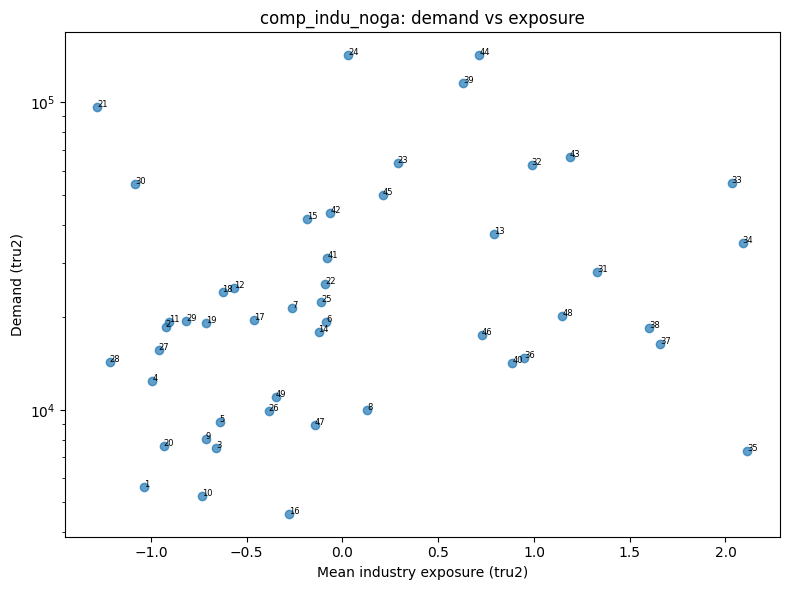

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_ind_scatter_full.png
comp_indu_noga Pearson: 0.183746278606095
comp_indu_noga Spearman: 0.32357142857142857
comp_indu_noga Weighted Pearson: 0.10154224398132873


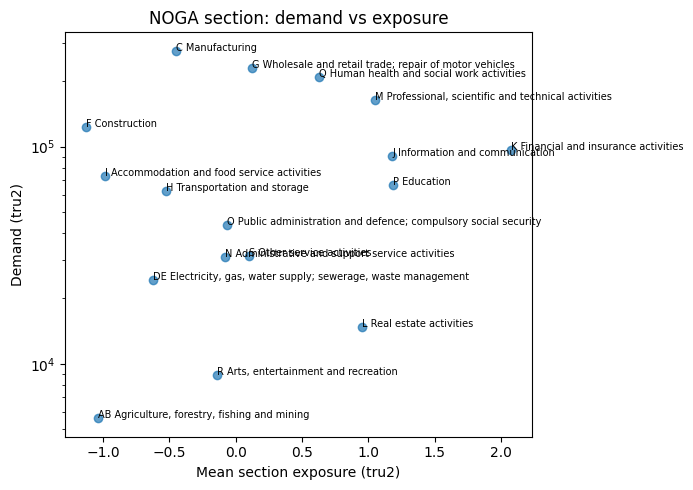

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_section_scatter_full.png


In [15]:
# Industry impact lists (comp_indu_noga + NOGA section)

# comp_indu_noga full list
_df["noga_code"] = _df["comp_indu_noga"].astype("string")
_df["noga_label"] = _df["comp_indu_noga_label"].fillna("Unknown")

ind_group = _df.groupby(["noga_code", "noga_label"])
ind_metrics = ind_group.agg(
    demand_total_tru2=("srvy_wght_tru2","sum"),
    postings_total_tru1=("srvy_wght_tru1","sum"),
    n_ads=("srvy_wght_tru2","size")
).reset_index()
ind_metrics["mean_ind_exp_tru2"] = ind_group.apply(lambda g: wmean(g, ind_exp_col)).values
ind_metrics = ind_metrics.sort_values("mean_ind_exp_tru2", ascending=False)
ind_metrics.to_csv(OUT_TABLES / "table_ind_full_comp_noga.csv", index=False)
print("Saved", OUT_TABLES / "table_ind_full_comp_noga.csv")

display(ind_metrics)

# NOGA section full list
_df["section_code"] = _df["industry_section"].astype("string")
_df["section_label"] = _df["industry_section_label"].fillna(_df["industry_section"]).fillna("Unknown")

sec_group = _df.groupby(["section_code", "section_label"])
sec_metrics = sec_group.agg(
    demand_total_tru2=("srvy_wght_tru2","sum"),
    postings_total_tru1=("srvy_wght_tru1","sum"),
    n_ads=("srvy_wght_tru2","size")
).reset_index()
sec_metrics["mean_sec_exp_tru2"] = sec_group.apply(lambda g: wmean(g, "industry_section_exposure_weighted")).values
sec_metrics = sec_metrics.sort_values("mean_sec_exp_tru2", ascending=False)
sec_metrics.to_csv(OUT_TABLES / "table_ind_full_section.csv", index=False)
print("Saved", OUT_TABLES / "table_ind_full_section.csv")

display(sec_metrics)


# Scatter: comp_indu_noga demand vs exposure (IDs only)
ind_plot = _finite_for_plot(ind_metrics, "mean_ind_exp_tru2", "demand_total_tru2", y_positive=True)
plt.figure(figsize=(8,6))
plt.scatter(ind_plot["mean_ind_exp_tru2"], ind_plot["demand_total_tru2"], alpha=0.7)
for _, row in ind_plot.iterrows():
    label = str(row["noga_code"])
    plt.text(row["mean_ind_exp_tru2"], row["demand_total_tru2"], label, fontsize=6)
plt.xlabel("Mean industry exposure (tru2)")
plt.ylabel("Demand (tru2)")
plt.yscale("log")
plt.title("comp_indu_noga: demand vs exposure")
plt.tight_layout()
fig_path = OUT_VIS / "fig_ind_scatter_full.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved", fig_path)
print_corr_metrics("comp_indu_noga", ind_plot, "mean_ind_exp_tru2", "demand_total_tru2")

# Scatter: NOGA section demand vs exposure
sec_plot = _finite_for_plot(sec_metrics, "mean_sec_exp_tru2", "demand_total_tru2", y_positive=True)
plt.figure(figsize=(7,5))
plt.scatter(sec_plot["mean_sec_exp_tru2"], sec_plot["demand_total_tru2"], alpha=0.7)
for _, row in sec_plot.iterrows():
    label = f"{row['section_code']} {row['section_label']}"
    plt.text(row["mean_sec_exp_tru2"], row["demand_total_tru2"], label, fontsize=7)
plt.xlabel("Mean section exposure (tru2)")
plt.ylabel("Demand (tru2)")
plt.yscale("log")
plt.title("NOGA section: demand vs exposure")
plt.tight_layout()
fig_path = OUT_VIS / "fig_section_scatter_full.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved", fig_path)


## 5) Regions 

### 5.1) Regions — occupation exposure


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/223835493.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  avg_ind_exp_by_kanton = indreg_group.apply(wmean_industry_exp).reset_index(name="mean_ind_exp_tru2")


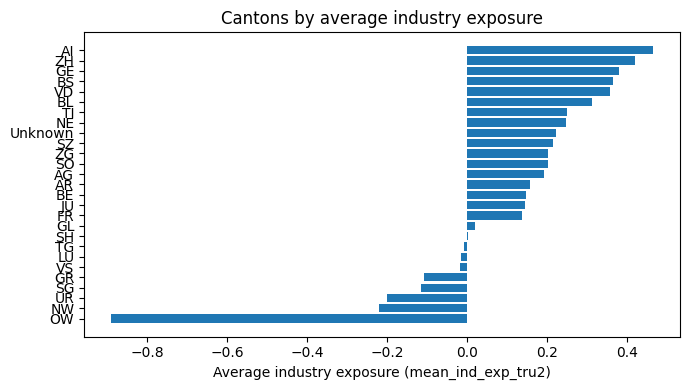

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_canton_top30_avg_industry_exposure.png


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/223835493.py:55: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  reg_metrics_ind["mean_ind_exp_tru2"] = ind_reg_group.apply(wmean_industry_exp)
/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/223835493.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  known_denom_ind = ind_reg_group.apply(lambda g: g.loc[g[ind_exp_col].notna(),

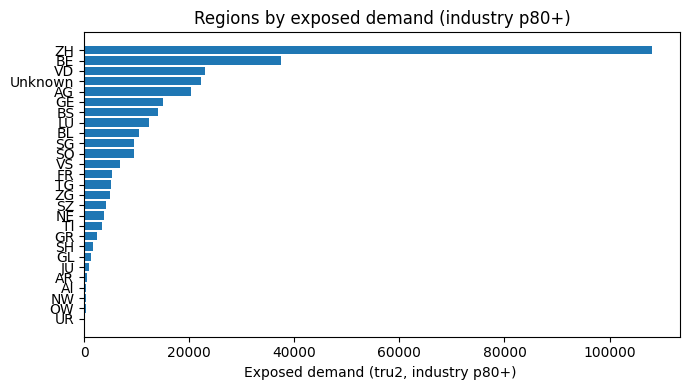

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_region_top15_exposed_p80_ind.png


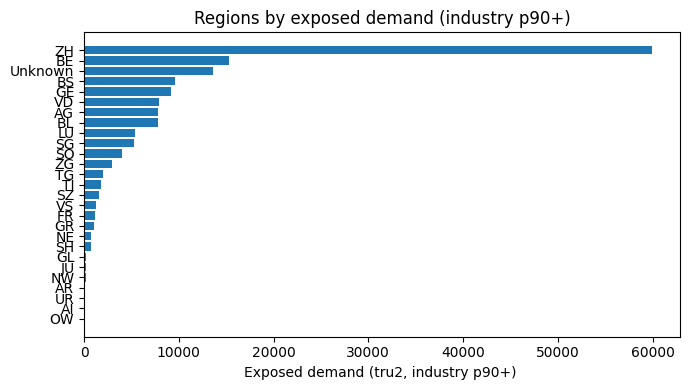

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_region_top15_exposed_p90_ind.png


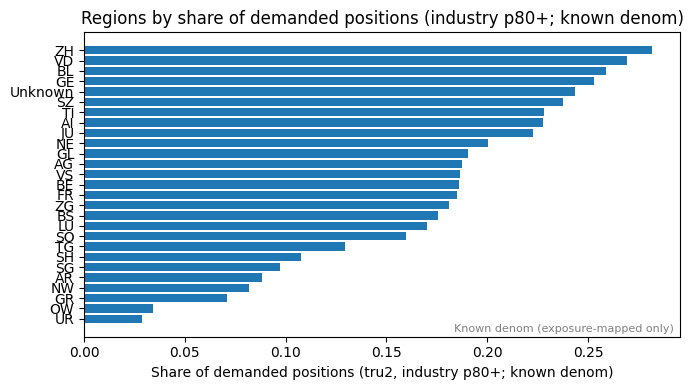

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_region_top30_share_p80_ind.png


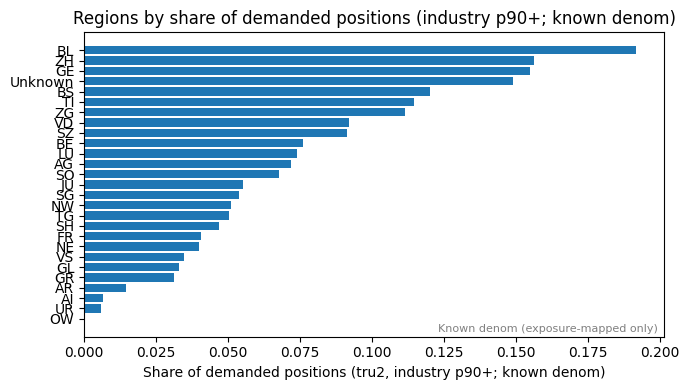

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_region_top30_share_p90_ind.png


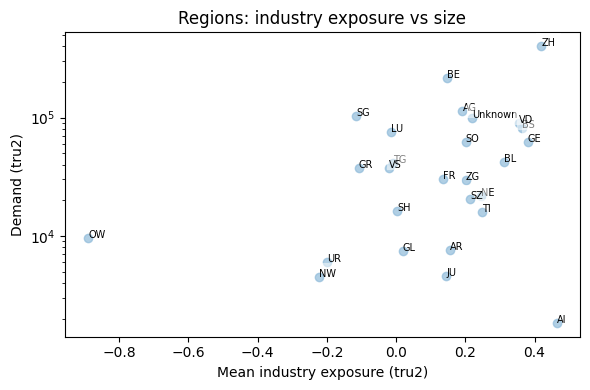

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_region_scatter_ind.png


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/223835493.py:196: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[ind_exp_col].dropna(), weights=g.loc[g[ind_exp_col].notna(), "srvy_wght_tru2"])


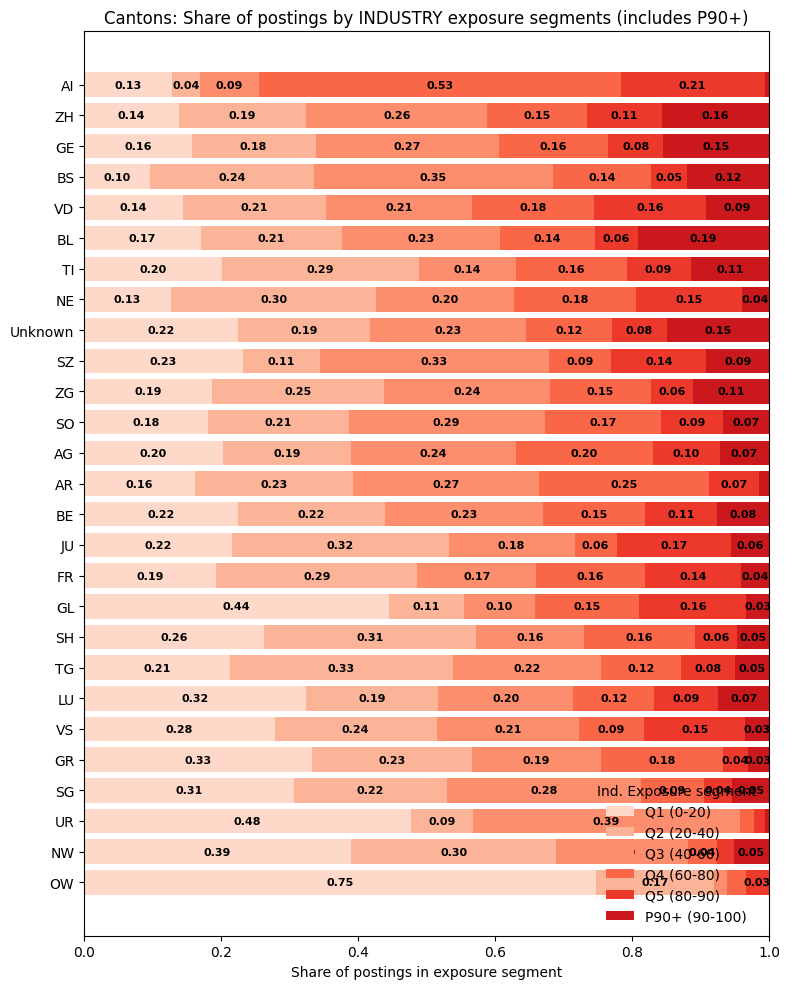

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_kanton_stack_segments_ind_exp.png


In [16]:
# ==== Plot: average industry exposure per canton ====
import textwrap
from matplotlib.patches import Patch

def _wrap_labels(labels, width=30):
    return [textwrap.fill(str(l), width=width) for l in labels]



import re

def _exp_from_label(lbl):
    m = re.search(r"exp=([+-]?\d*\.?\d+)", str(lbl))
    return float(m.group(1)) if m else float("nan")


def _legend_below(ax, handles=None, labels=None, title=None, ncol=4):
    if handles is None or labels is None:
        handles, labels = ax.get_legend_handles_labels()
    labels = _wrap_labels(labels, width=30)
    leg = ax.legend(handles, labels, title=title, ncol=ncol,
                    loc="upper center", bbox_to_anchor=(0.5, -0.12),
                    frameon=False, fontsize=8)
    return leg

# Compute weighted average industry exposure per canton
def wmean_industry_exp(g):
    x = g.loc[g[ind_exp_col].notna(), ind_exp_col]
    w = g.loc[g[ind_exp_col].notna(), "srvy_wght_tru2"]
    return np.average(x, weights=w) if len(x) else np.nan

indreg_group = _df.groupby(region_col)
avg_ind_exp_by_kanton = indreg_group.apply(wmean_industry_exp).reset_index(name="mean_ind_exp_tru2")

top_kanton_ind_exp = avg_ind_exp_by_kanton.nlargest(30, "mean_ind_exp_tru2")
plt.figure(figsize=(7,4))
plt.barh(top_kanton_ind_exp[region_col].astype(str), top_kanton_ind_exp["mean_ind_exp_tru2"])
plt.gca().invert_yaxis()
plt.xlabel("Average industry exposure (mean_ind_exp_tru2)")
plt.title("Cantons by average industry exposure")
plt.tight_layout()
fig_path = OUT_VIS / "fig_canton_top30_avg_industry_exposure.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved", fig_path)
# ==== End plot ====

# Region summary (industry exposure)
ind_reg_group = _df.groupby(region_col)

reg_metrics_ind = ind_reg_group.agg(
    demand_total_tru2=("srvy_wght_tru2","sum"),
    postings_total_tru1=("srvy_wght_tru1","sum")
)
reg_metrics_ind["mean_ind_exp_tru2"] = ind_reg_group.apply(wmean_industry_exp)

# exposed demand p80/p90 (industry)
reg_metrics_ind["exposed_demand_p80_ind"] = _df.loc[_df[ind_exp_col] >= ind_p80].groupby(region_col)["srvy_wght_tru2"].sum()
reg_metrics_ind["exposed_demand_p90_ind"] = _df.loc[_df[ind_exp_col] >= ind_p90].groupby(region_col)["srvy_wght_tru2"].sum()
reg_metrics_ind = reg_metrics_ind.fillna(0)

# shares
known_denom_ind = ind_reg_group.apply(lambda g: g.loc[g[ind_exp_col].notna(), "srvy_wght_tru2"].sum())
reg_metrics_ind["high_share_total_p80_ind"] = reg_metrics_ind["exposed_demand_p80_ind"] / reg_metrics_ind["demand_total_tru2"]
reg_metrics_ind["high_share_known_p80_ind"] = reg_metrics_ind["exposed_demand_p80_ind"] / known_denom_ind
reg_metrics_ind["coverage_share_ind"] = known_denom_ind / reg_metrics_ind["demand_total_tru2"]

reg_metrics_ind["high_share_total_p90_ind"] = reg_metrics_ind["exposed_demand_p90_ind"] / reg_metrics_ind["demand_total_tru2"]
reg_metrics_ind["high_share_known_p90_ind"] = reg_metrics_ind["exposed_demand_p90_ind"] / known_denom_ind
reg_metrics_ind = reg_metrics_ind.reset_index()
reg_metrics_ind.to_csv(OUT_TABLES / "table_region_summary_industry.csv", index=False)

# Bar charts: exposed demand p80/p90 (industry)
for thresh_label in ["p80","p90"]:
    col = f"exposed_demand_{thresh_label}_ind"
    top_reg = reg_metrics_ind.nlargest(30, col)
    plt.figure(figsize=(7,4))
    plt.barh(top_reg[region_col].astype(str), top_reg[col])
    plt.gca().invert_yaxis()
    plt.xlabel(f"Exposed demand (tru2, industry {thresh_label}+) ")
    plt.title(f"Regions by exposed demand (industry {thresh_label}+)")
    plt.tight_layout()
    fig_path = OUT_VIS / f"fig_region_top15_exposed_{thresh_label}_ind.png"
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print("Saved", fig_path)

# Bar charts: share of demanded positions (industry)

for thresh_label in ["p80", "p90"]:
    share_col = f"high_share_known_{thresh_label}_ind"
    plot_data = reg_metrics_ind.copy()
    plot_data[region_col] = plot_data[region_col].fillna("Unknown")
    plot_data[share_col] = pd.to_numeric(plot_data[share_col], errors="coerce").fillna(0)
    top_reg_share = plot_data.nlargest(30, share_col)
    plt.figure(figsize=(7,4))
    plt.barh(top_reg_share[region_col].astype(str), top_reg_share[share_col])
    plt.gca().invert_yaxis()
    plt.xlabel(f"Share of demanded positions (tru2, industry {thresh_label}+; known denom)")
    plt.title(f"Regions by share of demanded positions (industry {thresh_label}+; known denom)")
    plt.text(0.99, 0.01, 'Known denom (exposure-mapped only)', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=8, color='gray')
    plt.tight_layout()
    fig_path = OUT_VIS / f"fig_region_top30_share_{thresh_label}_ind.png"
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print("Saved", fig_path)





# Scatter (industry)
plt.figure(figsize=(6,4))
reg_ind_plot = _finite_for_plot(reg_metrics_ind, "mean_ind_exp_tru2", "demand_total_tru2", y_positive=True)
plt.scatter(reg_ind_plot["mean_ind_exp_tru2"], reg_ind_plot["demand_total_tru2"], alpha=0.7)
label_set = set()
label_set.update(reg_ind_plot.nlargest(30, "demand_total_tru2")[region_col].tolist())
label_set.update(reg_ind_plot.nlargest(30, "mean_ind_exp_tru2")[region_col].tolist())
if "Unknown" in reg_metrics_ind[region_col].values:
    label_set.add("Unknown")
for _, row in reg_ind_plot[reg_ind_plot[region_col].isin(label_set)].iterrows():
    plt.text(row["mean_ind_exp_tru2"], row["demand_total_tru2"], str(row[region_col]), fontsize=7,
             bbox=dict(facecolor="white", alpha=0.5, edgecolor="none"))
plt.xlabel("Mean industry exposure (tru2)")
plt.ylabel("Demand (tru2)")
plt.yscale("log")
plt.title("Regions: industry exposure vs size")
plt.tight_layout()
fig_path = OUT_VIS / "fig_region_scatter_ind.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved", fig_path)

# Decomposition: top 5 regions by exposed demand (industry p80)
reg_metrics_ind_sorted = reg_metrics_ind.sort_values("exposed_demand_p80_ind", ascending=False)
top_regions_ind = reg_metrics_ind_sorted.head(5)[region_col].tolist()
rows_occ_ind = []
rows_ind_ind = []
if "occ2_label" not in globals():
    occ2_label = _df["occu_isco2_label"].fillna("Unknown")
for reg in top_regions_ind:
    sub = _df[(_df[region_col] == reg) & (_df[ind_exp_col] >= ind_p80)]
    sub_occ = sub.groupby("occ2_label")["srvy_wght_tru2"].sum().sort_values(ascending=False).head(5)
    for rank, (code, val) in enumerate(sub_occ.items(), start=1):
        rows_occ_ind.append({"region": reg, "rank": rank, "occ2_label": code, "exposed_demand_tru2": val})
    sub_ind = sub.groupby(_df["comp_indu_noga_label"].fillna("Unknown"))["srvy_wght_tru2"].sum().sort_values(ascending=False).head(5)
    for rank, (code, val) in enumerate(sub_ind.items(), start=1):
        rows_ind_ind.append({"region": reg, "rank": rank, "indu_label": code, "exposed_demand_tru2": val})

pd.DataFrame(rows_occ_ind).to_csv(OUT_TABLES / "table_region_top_occ2_contrib_ind.csv", index=False)
pd.DataFrame(rows_ind_ind).to_csv(OUT_TABLES / "table_region_top_ind_contrib_ind.csv", index=False)



# === Plot: horizontal stacked bars for exposure segments per canton (INDUSTRY exposure, includes P90+) ===
# Build exposure segments using global p20/p40/p60/p80/p90 thresholds
ind_p20_seg, ind_p40_seg, ind_p60_seg = ind_p20, ind_p40, ind_p60
ind_p80_seg, ind_p90_seg = ind_p80, ind_p90

def _ind_segment(x):
    if pd.isna(x):
        return pd.NA
    if x <= ind_p20:
        return "Q1 (0-20)"
    if x <= ind_p40:
        return "Q2 (20-40)"
    if x <= ind_p60:
        return "Q3 (40-60)"
    if x <= ind_p80_seg:
        return "Q4 (60-80)"
    if x < ind_p90_seg:
        return "Q5 (80-90)"
    return "P90+ (90-100)"

_df["ind_exposure_segment"] = _df[ind_exp_col].apply(_ind_segment)
segments = ["Q1 (0-20)", "Q2 (20-40)", "Q3 (40-60)", "Q4 (60-80)", "Q5 (80-90)", "P90+ (90-100)"]

postings_per_kanton_segment_ind = (
    _df[_df[region_col].notna() & _df["ind_exposure_segment"].notna()]
    .groupby([region_col, "ind_exposure_segment"], observed=True)["srvy_wght_tru2"].sum()
    .unstack(fill_value=0)
)
for seg in segments:
    if seg not in postings_per_kanton_segment_ind.columns:
        postings_per_kanton_segment_ind[seg] = 0

postings_per_kanton_segment_share_ind = postings_per_kanton_segment_ind.div(
    postings_per_kanton_segment_ind.sum(axis=1), axis=0
)
postings_per_kanton_segment_share_ind = postings_per_kanton_segment_share_ind.loc[
    postings_per_kanton_segment_share_ind.sum(axis=1) > 0
]

mean_ind_exposure_by_kanton = (
    _df.groupby(region_col)
    .apply(lambda g: np.average(g[ind_exp_col].dropna(), weights=g.loc[g[ind_exp_col].notna(), "srvy_wght_tru2"])
           if g[ind_exp_col].notna().any() else 0)
)
plot_order_ind = mean_ind_exposure_by_kanton.loc[postings_per_kanton_segment_share_ind.index].sort_values(ascending=True).index.tolist()
postings_per_kanton_segment_share_ind = postings_per_kanton_segment_share_ind.loc[plot_order_ind]

fig, ax = plt.subplots(figsize=(8, 10))

colormap_ind = plt.get_cmap("Reds")
segment_colors = [colormap_ind(0.15 + 0.12*i) for i in range(len(segments))]

bottom = np.zeros(len(postings_per_kanton_segment_share_ind))
y_labels = postings_per_kanton_segment_share_ind.index.astype(str)

for i, seg in enumerate(segments):
    vals = postings_per_kanton_segment_share_ind[seg].values
    bars = ax.barh(
        y_labels,
        vals,
        left=bottom,
        height=0.8,
        color=segment_colors[i],
        label=seg
    )
    for j, (bar, share) in enumerate(zip(bars, vals)):
        if np.isfinite(share) and share >= 0.03:
            xpos = bottom[j] + share/2
            ypos = bar.get_y() + bar.get_height()/2
            ax.text(
                xpos,
                ypos,
                f"{share:.2f}",
                ha="center",
                va="center",
                color="black",
                fontsize=8,
                fontweight="bold"
            )
    bottom += vals

ax.set_xlabel("Share of postings in exposure segment")
ax.set_title("Cantons: Share of postings by INDUSTRY exposure segments (includes P90+)")
ax.set_xlim(0, 1)
ax.legend(title="Ind. Exposure segment", loc="lower right", frameon=False)
plt.tight_layout()

fig_path = OUT_VIS / "fig_kanton_stack_segments_ind_exp.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved", fig_path)









/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/1996986263.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  reg_metrics["mean_occ_exp_tru2"] = reg_group.apply(wmean_region_occ)
/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/1996986263.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  known_denom = reg_group.apply(lambda g: g.loc[g[occ_exp_col].notna(), "srvy_wght_tru2

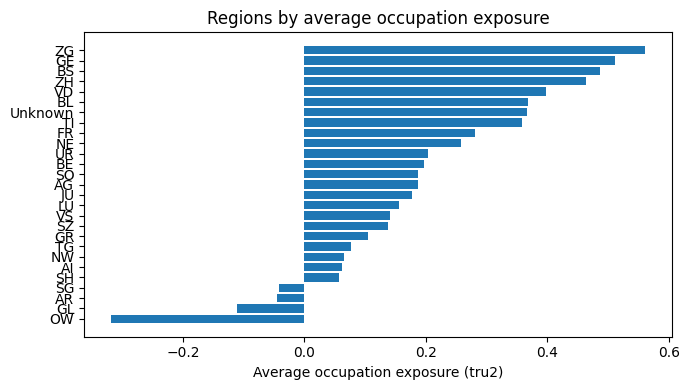

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_region_top30_avg_exposure.png


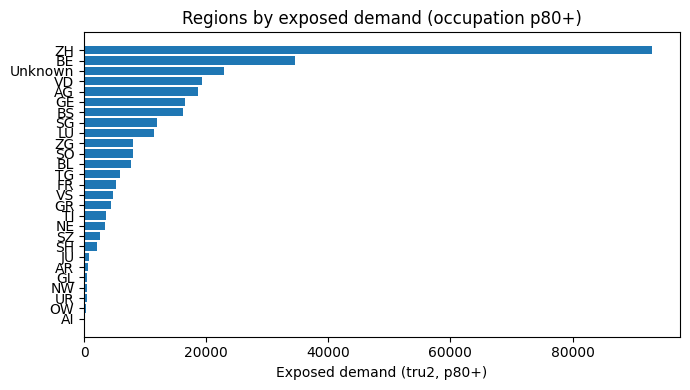

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_region_top15_exposed_p80.png


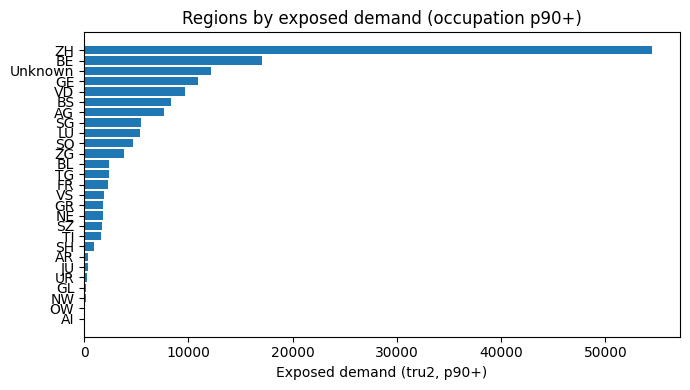

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_region_top15_exposed_p90.png


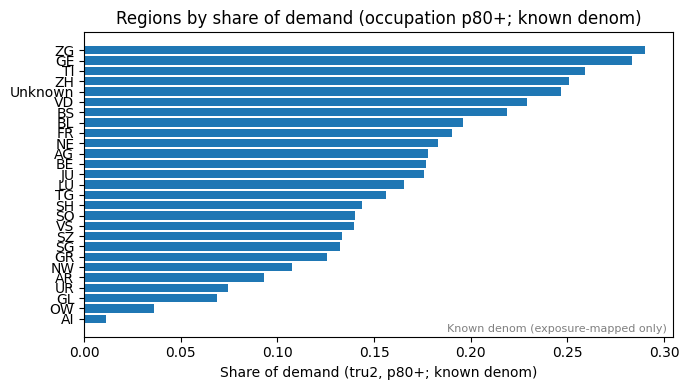

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_region_top30_share_p80.png


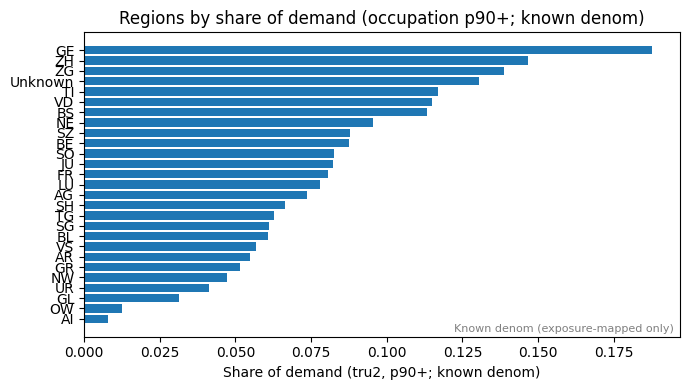

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_region_top30_share_p90.png


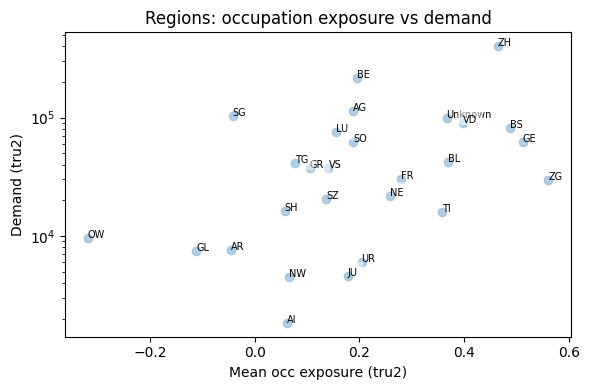

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_region_scatter.png


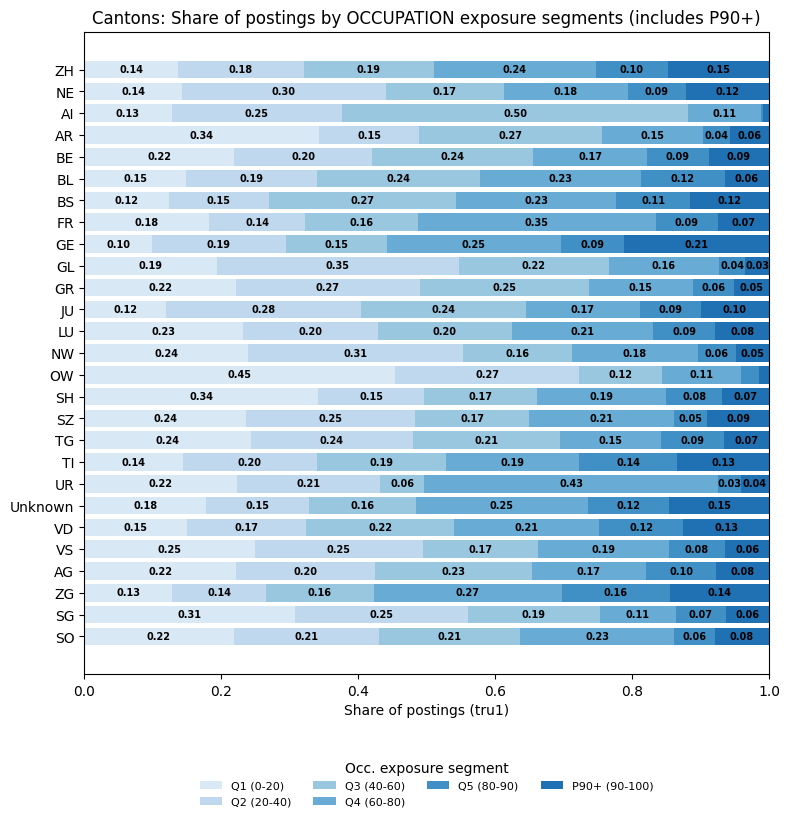

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_kanton_stack_segments_occ_exp.png


In [17]:
# === Region analysis (occupation exposure) ===
region_col = "loca_regi_kant_label"

# Region summary (occupation exposure)
reg_group = _df.groupby(region_col)

def wmean_region_occ(g):
    x = g.loc[g[occ_exp_col].notna(), occ_exp_col]
    w = g.loc[g[occ_exp_col].notna(), "srvy_wght_tru2"]
    return np.average(x, weights=w) if len(x) else np.nan

reg_metrics = reg_group.agg(
    demand_total_tru2=("srvy_wght_tru2", "sum"),
    postings_total_tru1=("srvy_wght_tru1", "sum")
)
reg_metrics["mean_occ_exp_tru2"] = reg_group.apply(wmean_region_occ)

# exposed demand p80/p90 (occupation)
reg_metrics["exposed_demand_p80"] = _df.loc[_df[occ_exp_col] >= occ_p80].groupby(region_col)["srvy_wght_tru2"].sum()
reg_metrics["exposed_demand_p90"] = _df.loc[_df[occ_exp_col] >= occ_p90].groupby(region_col)["srvy_wght_tru2"].sum()
reg_metrics = reg_metrics.fillna(0)

# shares (known denom)
known_denom = reg_group.apply(lambda g: g.loc[g[occ_exp_col].notna(), "srvy_wght_tru2"].sum())
reg_metrics["high_share_total_p80"] = reg_metrics["exposed_demand_p80"] / reg_metrics["demand_total_tru2"]
reg_metrics["high_share_known_p80"] = reg_metrics["exposed_demand_p80"] / known_denom
reg_metrics["coverage_share"] = known_denom / reg_metrics["demand_total_tru2"]

reg_metrics["high_share_total_p90"] = reg_metrics["exposed_demand_p90"] / reg_metrics["demand_total_tru2"]
reg_metrics["high_share_known_p90"] = reg_metrics["exposed_demand_p90"] / known_denom
reg_metrics = reg_metrics.reset_index()
reg_metrics.to_csv(OUT_TABLES / "table_region_summary.csv", index=False)

# Bar charts: mean exposure
_top = reg_metrics.nlargest(30, "mean_occ_exp_tru2")
plt.figure(figsize=(7,4))
plt.barh(_top[region_col].astype(str), _top["mean_occ_exp_tru2"])
plt.gca().invert_yaxis()
plt.xlabel("Average occupation exposure (tru2)")
plt.title("Regions by average occupation exposure")
plt.tight_layout()
fig_path = OUT_VIS / "fig_region_top30_avg_exposure.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved", fig_path)

# Bar charts: exposed demand p80/p90
for thresh_label in ["p80", "p90"]:
    col = f"exposed_demand_{thresh_label}"
    top_reg = reg_metrics.nlargest(30, col)
    plt.figure(figsize=(7,4))
    plt.barh(top_reg[region_col].astype(str), top_reg[col])
    plt.gca().invert_yaxis()
    plt.xlabel(f"Exposed demand (tru2, {thresh_label}+)")
    plt.title(f"Regions by exposed demand (occupation {thresh_label}+)")
    plt.tight_layout()
    fig_path = OUT_VIS / f"fig_region_top15_exposed_{thresh_label}.png"
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print("Saved", fig_path)

# Share of demand (known denom)
for thresh_label in ["p80", "p90"]:
    share_col = f"high_share_known_{thresh_label}"
    plot_data = reg_metrics.copy()
    plot_data[region_col] = plot_data[region_col].fillna("Unknown")
    plot_data[share_col] = pd.to_numeric(plot_data[share_col], errors="coerce").fillna(0)
    top_reg_share = plot_data.nlargest(30, share_col)
    plt.figure(figsize=(7,4))
    plt.barh(top_reg_share[region_col].astype(str), top_reg_share[share_col])
    plt.gca().invert_yaxis()
    plt.xlabel(f"Share of demand (tru2, {thresh_label}+; known denom)")
    plt.title(f"Regions by share of demand (occupation {thresh_label}+; known denom)")
    plt.text(0.99, 0.01, 'Known denom (exposure-mapped only)', transform=plt.gca().transAxes,
             ha='right', va='bottom', fontsize=8, color='gray')
    plt.tight_layout()
    fig_path = OUT_VIS / f"fig_region_top30_share_{thresh_label}.png"
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print("Saved", fig_path)

# Scatter: exposure vs demand
plt.figure(figsize=(6,4))
reg_plot = _finite_for_plot(reg_metrics, "mean_occ_exp_tru2", "demand_total_tru2", y_positive=True)
plt.scatter(reg_plot["mean_occ_exp_tru2"], reg_plot["demand_total_tru2"], alpha=0.7)
label_set = set()
label_set.update(reg_plot.nlargest(30, "demand_total_tru2")[region_col].tolist())
label_set.update(reg_plot.nlargest(30, "mean_occ_exp_tru2")[region_col].tolist())
if "Unknown" in reg_metrics[region_col].values:
    label_set.add("Unknown")
for _, row in reg_plot[reg_plot[region_col].isin(label_set)].iterrows():
    plt.text(row["mean_occ_exp_tru2"], row["demand_total_tru2"], str(row[region_col]), fontsize=7,
             bbox=dict(facecolor="white", alpha=0.5, edgecolor="none"))
plt.xlabel("Mean occ exposure (tru2)")
plt.ylabel("Demand (tru2)")
plt.yscale("log")
plt.title("Regions: occupation exposure vs demand")
plt.tight_layout()
fig_path = OUT_VIS / "fig_region_scatter.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved", fig_path)

# Top contributors for top regions by exposed demand (p80)
reg_metrics_sorted = reg_metrics.sort_values("exposed_demand_p80", ascending=False)
top_regions = reg_metrics_sorted.head(5)[region_col].tolist()
rows_occ = []
rows_ind = []
for reg in top_regions:
    sub = _df[(_df[region_col] == reg) & (_df[occ_exp_col] >= occ_p80)]
    # top occ2
    sub_occ = sub.groupby("occ2_label")["srvy_wght_tru2"].sum().sort_values(ascending=False).head(5)
    for rank, (code, val) in enumerate(sub_occ.items(), start=1):
        rows_occ.append({"region": reg, "rank": rank, "occ2_label": code, "exposed_demand_tru2": val})
    # top industries
    sub_ind = sub.groupby(_df["comp_indu_noga_label"].fillna("Unknown"))["srvy_wght_tru2"].sum().sort_values(ascending=False).head(5)
    for rank, (code, val) in enumerate(sub_ind.items(), start=1):
        rows_ind.append({"region": reg, "rank": rank, "indu_label": code, "exposed_demand_tru2": val})

pd.DataFrame(rows_occ).to_csv(OUT_TABLES / "table_region_top_occ2_contrib.csv", index=False)
pd.DataFrame(rows_ind).to_csv(OUT_TABLES / "table_region_top_ind_contrib.csv", index=False)

# --- Plot: share of postings by occupation exposure segments ---
# define segments using weighted thresholds

def _occ_segment(x):
    if pd.isna(x):
        return pd.NA
    if x <= occ_p20:
        return "Q1 (0-20)"
    if x <= occ_p40:
        return "Q2 (20-40)"
    if x <= occ_p60:
        return "Q3 (40-60)"
    if x <= occ_p80:
        return "Q4 (60-80)"
    if x < occ_p90:
        return "Q5 (80-90)"
    return "P90+ (90-100)"

_df["occ_exposure_segment"] = _df[occ_exp_col].apply(_occ_segment)
segments = ["Q1 (0-20)", "Q2 (20-40)", "Q3 (40-60)", "Q4 (60-80)", "Q5 (80-90)", "P90+ (90-100)"]

seg_df = _df[_df[region_col].notna() & _df["occ_exposure_segment"].notna()]
postings_per_kanton_segment = (
    seg_df.groupby([region_col, "occ_exposure_segment"], observed=True)["srvy_wght_tru1"].sum()
          .unstack(fill_value=0)
)
for seg in segments:
    if seg not in postings_per_kanton_segment.columns:
        postings_per_kanton_segment[seg] = 0

postings_per_kanton_segment_share = postings_per_kanton_segment.div(
    postings_per_kanton_segment.sum(axis=1), axis=0
)
postings_per_kanton_segment_share = postings_per_kanton_segment_share.loc[
    postings_per_kanton_segment_share.sum(axis=1) > 0
]

plot_order_occ = postings_per_kanton_segment_share.sum(axis=1).sort_values().index
postings_per_kanton_segment_share = postings_per_kanton_segment_share.loc[plot_order_occ]

fig, ax = plt.subplots(figsize=(8, 10))
colormap = plt.get_cmap("Blues")
segment_colors = [colormap(0.15 + 0.12*i) for i in range(len(segments))]

bottom = np.zeros(len(postings_per_kanton_segment_share))
y_labels = postings_per_kanton_segment_share.index.astype(str)
for i, seg in enumerate(segments):
    vals = postings_per_kanton_segment_share[seg].values
    bars = ax.barh(y_labels, vals, left=bottom, height=0.8, color=segment_colors[i], label=seg)
    for j, (bar, share) in enumerate(zip(bars, vals)):
        if np.isfinite(share) and share >= 0.03:
            ax.text(bottom[j] + share/2, bar.get_y() + bar.get_height()/2, f"{share:.2f}",
                    ha="center", va="center", color="black", fontsize=7, fontweight="bold")
    bottom += vals

ax.set_xlabel("Share of postings (tru1)")
ax.set_title("Cantons: Share of postings by OCCUPATION exposure segments (includes P90+)")
ax.set_xlim(0, 1)
_legend_below(ax, title="Occ. exposure segment", ncol=4)
plt.tight_layout()
plt.subplots_adjust(bottom=0.32)
fig_path = OUT_VIS / "fig_kanton_stack_segments_occ_exp.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved", fig_path)


### 5.2) Regions — industry exposure



### 5.3) Canton composition differences: High vs Low exposure (Δ-share)
- Compare mean canton composition shares between **High** and **Low** exposure cantons (terciles).
- Δ‑share = mean share (High) − mean share (Low); shown in percentage points.
- Positive = more prevalent in high‑exposure cantons; negative = more prevalent in low‑exposure cantons.


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/1678867973.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df[known].groupby(region_col).apply(
/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/1678867973.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: wmean(g[exp_col], g["srvy_wght_tru2"]))


,group_label,mean_high_share,mean_low_share,delta_share_pp,rank
6,Construction,0.055296,0.137383,-8.208706,1
0,Accommodation and food service activities,0.036994,0.102876,-6.588166,2
12,Manufacturing,0.168021,0.190068,-2.204707,3
8,"Electricity, gas, water supply; sewerage, wast...",0.006967,0.024081,-1.711431,4
7,Education,0.043511,0.053725,-1.021379,5
15,Public administration and defence; compulsory ...,0.029275,0.034406,-0.513102,6
3,Administrative and support service activities,0.01909,0.022704,-0.361417,7
2,Activities of households as employers,0.018093,0.020777,-0.268455,8
4,"Agriculture, forestry, fishing and mining",0.003615,0.003515,0.009951,9
13,Other service activities,0.014995,0.014445,0.054978,10


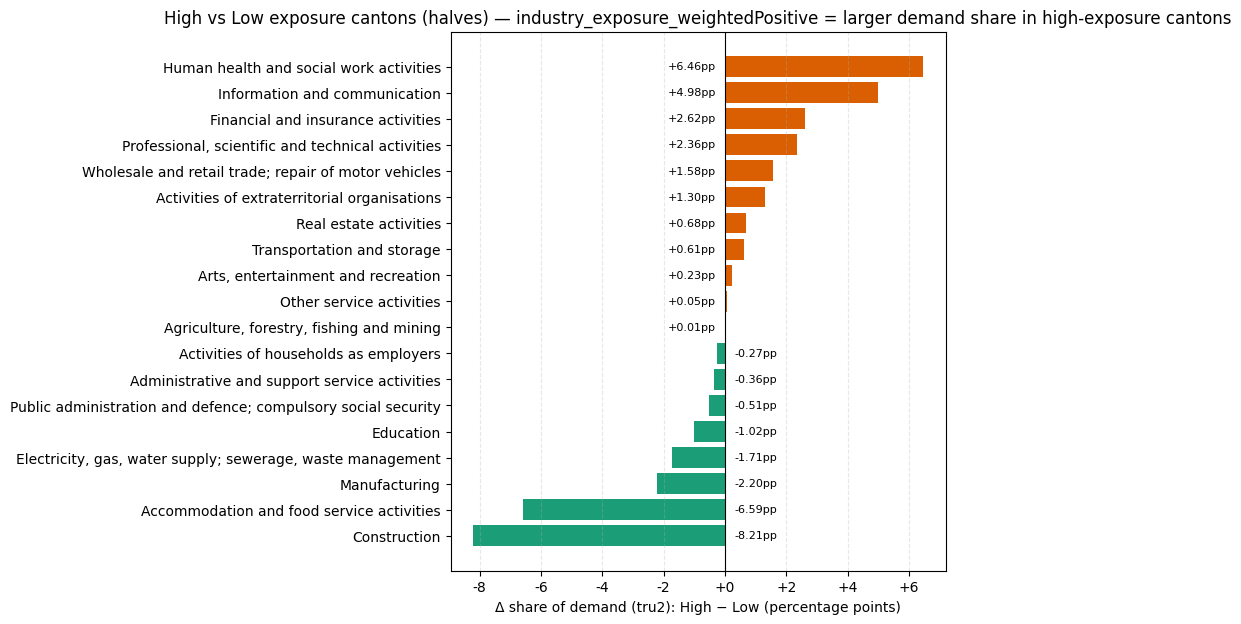

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_delta_share_noga_section_highlow_pretty.png


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/1678867973.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df[known].groupby(region_col).apply(
/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/1678867973.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: wmean(g[exp_col], g["srvy_wght_tru2"]))


,group_label,mean_high_share,mean_low_share,delta_share_pp,rank
2,Craft and related trades workers,0.124523,0.204008,-7.94855,1
7,Service and sales workers,0.130143,0.186316,-5.617267,2
5,"Plant and machine operators, and assemblers",0.029166,0.036099,-0.693305,3
3,Elementary occupations,0.02017,0.022513,-0.234376,4
0,Armed forces occupations,0.000792,0.002137,-0.134577,5
8,"Skilled agricultural, forestry and fishery wor...",0.006493,0.005693,0.079967,6
9,Technicians and associate professionals,0.198562,0.193573,0.498878,7
4,Managers,0.058086,0.040268,1.781853,8
1,Clerical support workers,0.118196,0.077525,4.067072,9
6,Professionals,0.313869,0.231866,8.200306,10


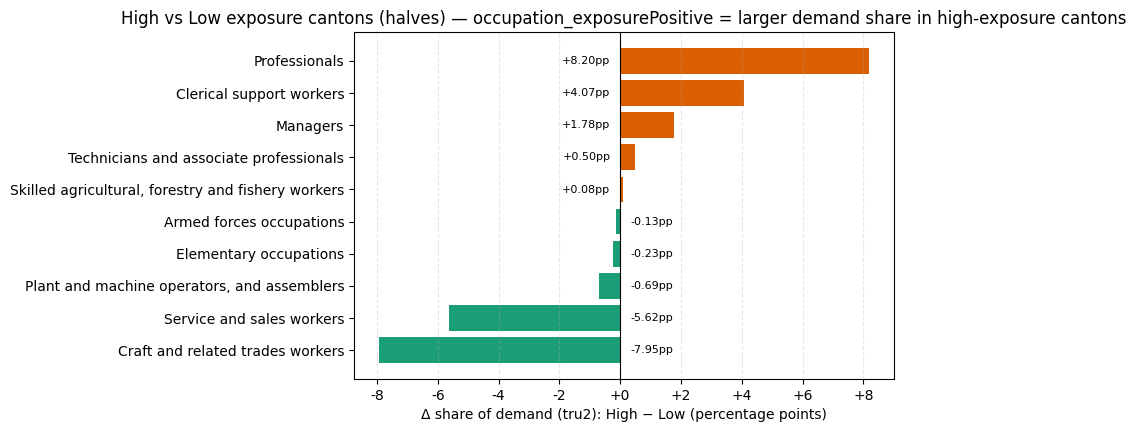

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_delta_share_isco1_highlow_pretty.png


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/1678867973.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df[known].groupby(region_col).apply(


,group_label,mean_high_share,mean_low_share,delta_share_pp,rank
12,Electrical and electronic trades workers,0.024391,0.064207,-3.98157,1
31,Personal service workers,0.057974,0.094277,-3.630251,2
4,Building and related trades workers (excluding...,0.036823,0.066867,-3.004446,3
39,Teaching professionals,0.028724,0.048891,-2.016721,4
18,Health professionals,0.054162,0.073293,-1.91313,5
35,Sales workers,0.047831,0.066635,-1.880476,6
20,Information and communications technicians,0.010564,0.027803,-1.723896,7
27,"Metal, machinery and related trades workers",0.045571,0.058445,-1.287338,8
11,Drivers and mobile plant operators,0.013277,0.019953,-0.667602,9
14,"Food processing, woodworking, garment and othe...",0.005869,0.011606,-0.573795,10


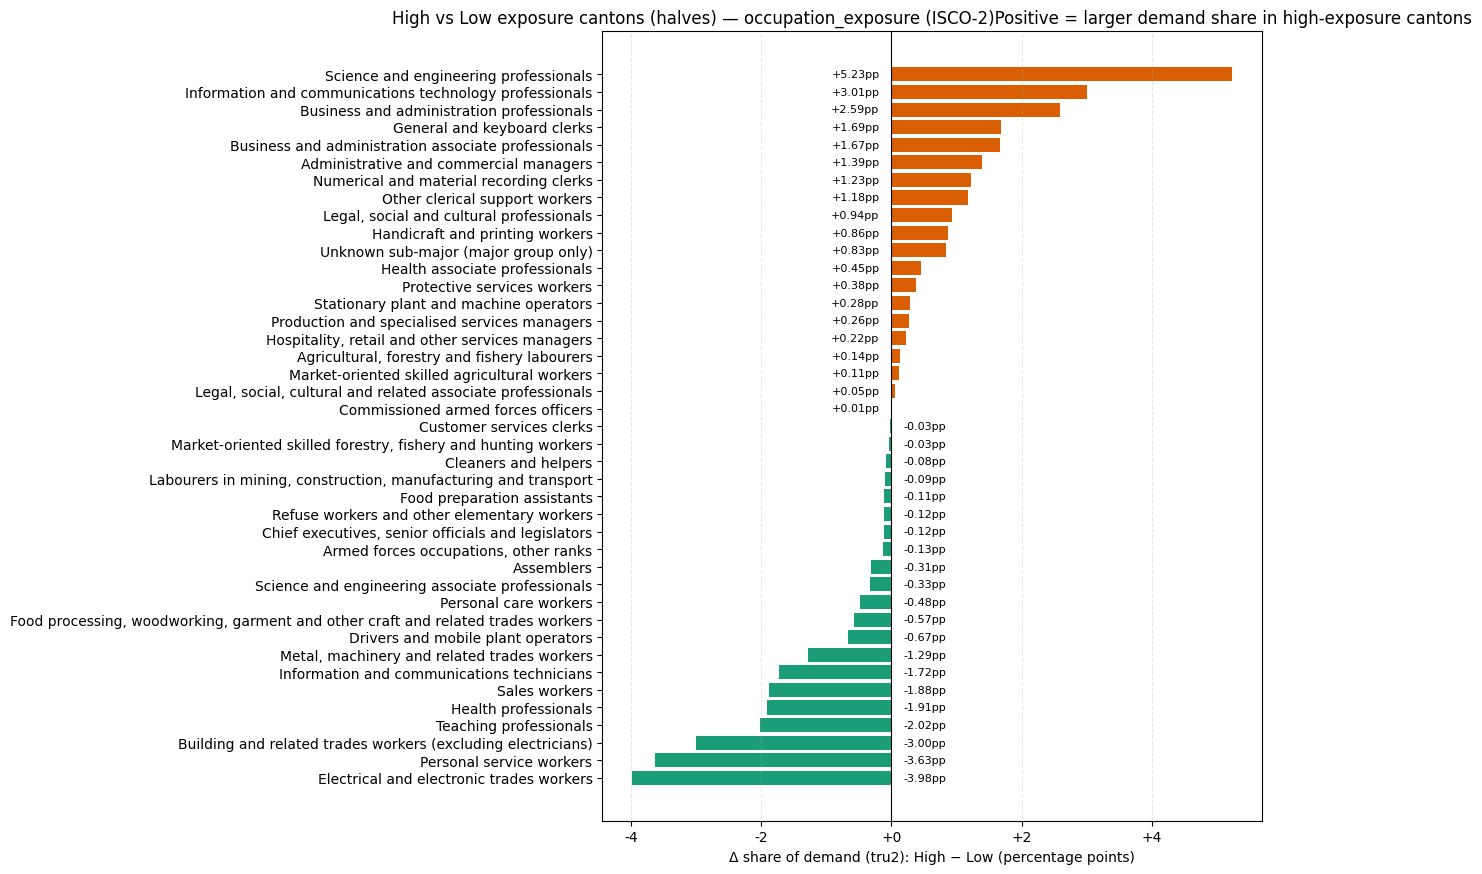

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_delta_share_isco2_highlow_pretty.png


In [18]:
region_col = "loca_regi_kant_label" if "loca_regi_kant_label" in _df.columns else "loca_regi_kant"


# --- Δ-share plots: High vs Low exposure cantons ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Display top/bottom groups (set to None to show all)
TOPK_NOGA = 8
TOPK_ISCO = 6


def wmean(series, weights):
    if series.empty:
        return np.nan
    return np.average(series, weights=weights)


def canton_exposure_scores(df, exp_col):
    known = df[exp_col].notna()
    return df[known].groupby(region_col).apply(
        lambda g: wmean(g[exp_col], g["srvy_wght_tru2"])
    )


def make_canton_shares(df, group_col):
    tmp = (
        df.groupby([region_col, group_col])["srvy_wght_tru2"].sum()
          .reset_index()
    )
    totals = tmp.groupby(region_col)["srvy_wght_tru2"].sum().rename("total").reset_index()
    tmp = tmp.merge(totals, on=region_col, how="left")
    tmp["share"] = tmp["srvy_wght_tru2"] / tmp["total"]
    pivot = tmp.pivot(index=region_col, columns=group_col, values="share").fillna(0)
    return pivot


def canton_group_exposure(df, group_col, exp_col):
    # exp_cg: weighted mean exposure within (canton, group), known exposure only
    tmp = df[df[exp_col].notna()].copy()
    tmp = (
        tmp.groupby([region_col, group_col])
           .apply(lambda g: wmean(g[exp_col], g["srvy_wght_tru2"]))
           .reset_index(name="exp_cg")
    )
    pivot = tmp.pivot(index=region_col, columns=group_col, values="exp_cg")
    return pivot


def high_low_groups(exposure_scores):
    # Drop Unknown canton
    if "Unknown" in exposure_scores.index:
        exposure_scores = exposure_scores.drop("Unknown")
    # Rank-based halves to handle ties (median split)
    ranks = exposure_scores.rank(method="first")
    half = pd.qcut(ranks, q=2, labels=["Low", "High"])
    return half


def delta_share_table(shares, group_assign):
    # Align
    shares = shares.loc[group_assign.index]
    high = shares.loc[group_assign == "High"]
    low = shares.loc[group_assign == "Low"]
    mean_high = high.mean(axis=0)
    mean_low = low.mean(axis=0)
    delta = (mean_high - mean_low) * 100  # percentage points
    out = pd.DataFrame({
        "group_label": delta.index,
        "mean_high_share": mean_high.values,
        "mean_low_share": mean_low.values,
        "delta_share_pp": delta.values,
    }).sort_values("delta_share_pp")
    out["rank"] = np.arange(1, len(out)+1)
    return out


def ensure_group_label(df):
    if 'group_label' in df.columns:
        return df
    name = df.index.name or 'index'
    df = df.reset_index().rename(columns={name: 'group_label'})
    return df


def plot_delta_bar(df_delta, title, subtitle, fig_name, figsize, left_adjust, topk=None, label_at_zero=False):
    if "group_label" not in df_delta.columns:
        df_delta = df_delta.copy()
        df_delta["group_label"] = df_delta.index.astype(str)
    # Select top/bottom
    if topk is not None and topk > 0:
        sel = pd.concat([df_delta.head(topk), df_delta.tail(topk)])
    else:
        sel = df_delta
    sel = sel.sort_values("delta_share_pp")

    fig, ax = plt.subplots(figsize=figsize)
    colors = ["#1b9e77" if v < 0 else "#d95f02" for v in sel["delta_share_pp"]]
    bars = ax.barh(sel["group_label"], sel["delta_share_pp"], color=colors)
    if label_at_zero:
        ax.set_yticklabels([])
        for bar, label, v in zip(bars, sel["group_label"], sel["delta_share_pp"]):
            y = bar.get_y() + bar.get_height() / 2
            x = 0
            ax.text(x + (0.2 if v >= 0 else -0.2), y, str(label),
                    va="center", ha="left" if v >= 0 else "right", fontsize=8)
    ax.axvline(0, color="black", lw=0.8)
    ax.grid(axis='x', linestyle='--', alpha=0.3)

    # Value labels near zero line, on opposite side of axis from bar
    rng = sel["delta_share_pp"].max() - sel["delta_share_pp"].min()
    xpad = 0.02 * rng if rng > 0 else 0.1
    for bar, v in zip(bars, sel["delta_share_pp"]):
        y = bar.get_y() + bar.get_height() / 2
        if v >= 0:
            x = -xpad
            ha = "right"
        else:
            x = xpad
            ha = "left"
        val = (0.01 if abs(v) < 0.01 else abs(v)) * (1 if v >= 0 else -1)
        ax.text(x, y, f"{val:+.2f}pp", va="center", ha=ha, fontsize=8)

    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:+.0f}"))
    ax.set_xlabel("Δ share of demand (tru2): High − Low (percentage points)")
    ax.set_title(title + "" + subtitle)

    fig.subplots_adjust(left=left_adjust)
    fig_path = OUT_VIS / fig_name
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print("Saved", fig_path)


def _align_cols(*series_list):
    # Align multiple Series on shared index (inner join)
    idx = series_list[0].index
    for s in series_list[1:]:
        idx = idx.intersection(s.index)
    return [s.reindex(idx) for s in series_list]



# === NOGA section Δ-share ===
noga_label_col = "industry_section_label" if "industry_section_label" in _df.columns else "noga_section_label"
noga_df = _df.copy()
# Remove Unknown category from predictors
noga_df = noga_df[noga_df[noga_label_col].notna()]
noga_df = noga_df[noga_df[noga_label_col] != "Unknown"]

ind_exp_scores = canton_exposure_scores(noga_df, ind_exp_col)
group_assign_ind = high_low_groups(ind_exp_scores)
noga_shares = make_canton_shares(noga_df, noga_label_col)
noga_shares = noga_shares.loc[group_assign_ind.index]

# group exposure within canton
noga_exp_cg = canton_group_exposure(noga_df, noga_label_col, ind_exp_col)
noga_exp_cg = noga_exp_cg.loc[group_assign_ind.index]

delta_noga = delta_share_table(noga_shares, group_assign_ind)
delta_noga = ensure_group_label(delta_noga)

delta_noga.to_csv(OUT_TABLES / "table_canton_highlow_delta_share_noga_section.csv", index=False)

display(delta_noga)
plot_delta_bar(
    delta_noga,
    title="High vs Low exposure cantons (halves) — industry_exposure_weighted",
    subtitle="Positive = larger demand share in high‑exposure cantons",
    fig_name="fig_delta_share_noga_section_highlow_pretty.png",
    figsize=(11, 7),
    left_adjust=0.45,
    topk=None,
)


# === ISCO-1 Δ-share ===
isco_label_col = "occu_isco1_label" if "occu_isco1_label" in _df.columns else "occ1_label"
isco_df = _df.copy()
isco_df = isco_df[isco_df[isco_label_col].notna()]
isco_df = isco_df[isco_df[isco_label_col] != "Unknown"]

occ_exp_scores = canton_exposure_scores(isco_df, occ_exp_col)
group_assign_occ = high_low_groups(occ_exp_scores)
isco_shares = make_canton_shares(isco_df, isco_label_col)
isco_shares = isco_shares.loc[group_assign_occ.index]

# group exposure within canton
isco_exp_cg = canton_group_exposure(isco_df, isco_label_col, occ_exp_col)
isco_exp_cg = isco_exp_cg.loc[group_assign_occ.index]

delta_isco = delta_share_table(isco_shares, group_assign_occ)
delta_isco = ensure_group_label(delta_isco)

delta_isco.to_csv(OUT_TABLES / "table_canton_highlow_delta_share_isco1.csv", index=False)

display(delta_isco)
plot_delta_bar(
    delta_isco,
    title="High vs Low exposure cantons (halves) — occupation_exposure",
    subtitle="Positive = larger demand share in high‑exposure cantons",
    fig_name="fig_delta_share_isco1_highlow_pretty.png",
    figsize=(9, 4.5),
    left_adjust=0.30,
    topk=None,
    label_at_zero=False,
)

# === ISCO-2 Δ-share ===
isco2_label_col = "occu_isco2_label" if "occu_isco2_label" in _df.columns else "occ2_label"
isco2_df = _df.copy()
isco2_df = isco2_df[isco2_df[isco2_label_col].notna()]
isco2_df = isco2_df[isco2_df[isco2_label_col] != "Unknown"]

occ2_exp_scores = canton_exposure_scores(isco2_df, occ_exp_col)
group_assign_occ2 = high_low_groups(occ2_exp_scores)
isco2_shares = make_canton_shares(isco2_df, isco2_label_col)
isco2_shares = isco2_shares.loc[group_assign_occ2.index]

delta_isco2 = delta_share_table(isco2_shares, group_assign_occ2)
delta_isco2 = ensure_group_label(delta_isco2)

fig_h_isco2 = max(6, 0.25 * len(delta_isco2))

delta_isco2.to_csv(OUT_TABLES / "table_canton_highlow_delta_share_isco2.csv", index=False)

display(delta_isco2)
plot_delta_bar(
    delta_isco2,
    title="High vs Low exposure cantons (halves) — occupation_exposure (ISCO‑2)",
    subtitle="Positive = larger demand share in high‑exposure cantons",
    fig_name="fig_delta_share_isco2_highlow_pretty.png",
    figsize=(11, fig_h_isco2),
    left_adjust=0.30,
    topk=None,
    label_at_zero=False,
)


### 5.4 Canton exposure changes over time
Period averages (tru2-weighted) for canton exposure by period, plus growth metrics.


In [19]:


# Canton exposure changes over time (occupation + industry)

region_col = "loca_regi_kant_label" if "loca_regi_kant_label" in _df.columns else "loca_regi_kant"

periods = [(2010, 2014), (2015, 2019), (2020, 2024)]
period_labels = ["2010_2014", "2015_2019", "2020_2024"]


def _period_mask(df, start, end):
    return (df["adve_time_year"] >= start) & (df["adve_time_year"] <= end)


def _weighted_mean(group, exp_col):
    sub = group[group[exp_col].notna()]
    if sub.empty:
        return float('nan')
    w = sub["srvy_wght_tru2"]
    return (sub[exp_col] * w).sum() / w.sum() if w.sum() else float('nan')


def build_canton_table(exp_col, out_name):
    rows = []
    for (start, end), label in zip(periods, period_labels):
        g = _df[_period_mask(_df, start, end)].groupby(region_col)
        vals = g.apply(lambda x: _weighted_mean(x, exp_col)).rename(label)
        rows.append(vals)

    wide = pd.concat(rows, axis=1).reset_index()

    # growth metrics (percent change relative to |baseline|)
    p1, p2, p3 = period_labels
    def abs_change(a, b):
        if pd.isna(a) or pd.isna(b):
            return float('nan')
        return b - a
        if pd.isna(a) or pd.isna(b) or a == 0:
            return float('nan')
        return (b - a) / abs(a)

    wide["growth_p1_p2"] = wide.apply(lambda r: abs_change(r[p1], r[p2]), axis=1)
    wide["growth_p2_p3"] = wide.apply(lambda r: abs_change(r[p2], r[p3]), axis=1)
    wide["growth_p1_p3"] = wide.apply(lambda r: abs_change(r[p1], r[p3]), axis=1)
    wide["avg_growth"] = wide[["growth_p1_p2", "growth_p2_p3"]].mean(axis=1)

    wide.to_csv(OUT_TABLES / out_name, index=False)
    return wide

occ_canton_trends = build_canton_table(occ_exp_col, "table_canton_occ_exposure_trends.csv")
ind_canton_trends = build_canton_table(ind_exp_col, "table_canton_ind_exposure_trends.csv")

print("Saved", OUT_TABLES / "table_canton_occ_exposure_trends.csv")
print("Saved", OUT_TABLES / "table_canton_ind_exposure_trends.csv")

# show samples
print("Occupation exposure (sample):")
display(occ_canton_trends)
print("Industry exposure (sample):")
display(ind_canton_trends)


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/1589726875.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vals = g.apply(lambda x: _weighted_mean(x, exp_col)).rename(label)
/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/1589726875.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vals = g.apply(lambda x: _weighted_mean(x, exp_col)).rename(label)
/var/folders/b8/xcnl

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/tables/table_canton_occ_exposure_trends.csv
Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/tables/table_canton_ind_exposure_trends.csv
Occupation exposure (sample):


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/1589726875.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vals = g.apply(lambda x: _weighted_mean(x, exp_col)).rename(label)
/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/1589726875.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vals = g.apply(lambda x: _weighted_mean(x, exp_col)).rename(label)
/var/folders/b8/xcnl

,loca_regi_kant_label,2010_2014,2015_2019,2020_2024,growth_p1_p2,growth_p2_p3,growth_p1_p3,avg_growth
0,AG,0.220589,0.210772,0.138974,-0.009816,-0.071798,-0.081614,-0.040807
1,AI,0.331249,-0.289597,-0.037718,-0.620846,0.251879,-0.368966,-0.184483
2,AR,0.090395,0.089796,-0.232912,-0.000599,-0.322708,-0.323307,-0.161654
3,BE,0.245799,0.200255,0.155266,-0.045544,-0.044989,-0.090533,-0.045266
4,BL,0.333029,0.213301,0.446486,-0.119728,0.233185,0.113457,0.056728
5,BS,0.410382,0.471906,0.579551,0.061524,0.107645,0.169170,0.084585
6,FR,0.360216,0.138795,0.325976,-0.221421,0.187181,-0.034240,-0.017120
7,GE,0.724565,0.479092,0.410673,-0.245473,-0.068419,-0.313892,-0.156946
8,GL,0.314292,-0.332527,0.132933,-0.646819,0.465460,-0.181359,-0.090680
9,GR,0.238640,0.078209,0.006685,-0.160431,-0.071524,-0.231955,-0.115978


Industry exposure (sample):


,loca_regi_kant_label,2010_2014,2015_2019,2020_2024,growth_p1_p2,growth_p2_p3,growth_p1_p3,avg_growth
0,AG,0.098021,0.161598,0.302893,0.063577,0.141295,0.204872,0.102436
1,AI,0.685104,0.212154,0.323800,-0.472949,0.111645,-0.361304,-0.180652
2,AR,0.130581,0.277002,0.095927,0.146420,-0.181075,-0.034655,-0.017327
3,BE,0.026546,0.159102,0.236629,0.132556,0.077528,0.210084,0.105042
4,BL,0.078105,0.069548,0.503163,-0.008557,0.433615,0.425058,0.212529
5,BS,0.223582,0.323884,0.549144,0.100303,0.225260,0.325562,0.162781
6,FR,0.103393,0.066920,0.205974,-0.036473,0.139054,0.102581,0.051290
7,GE,0.605732,0.312612,0.293451,-0.293121,-0.019160,-0.312281,-0.156140
8,GL,0.284621,-0.127422,0.226580,-0.412043,0.354003,-0.058040,-0.029020
9,GR,-0.080628,-0.180701,-0.048721,-0.100072,0.131979,0.031907,0.015954


In [26]:
# 6.4b Top 5 group share changes (pp) per canton: NOGA section + ISCO-2 (separate tables)

region_col = "loca_regi_kant_label" if "loca_regi_kant_label" in _df.columns else "loca_regi_kant"

period1 = (2010, 2014)
period2 = (2020, 2024)

noga_label_col = "industry_section_label" if "industry_section_label" in _df.columns else "noga_section_label"
isco2_label_col = "occu_isco2_label" if "occu_isco2_label" in _df.columns else "occ2_label"

# Helper to compute share table for a period

def period_group_shares(df, group_col, start, end):
    sub = df[(df['adve_time_year'] >= start) & (df['adve_time_year'] <= end)].copy()
    tmp = (
        sub.groupby([region_col, group_col])["srvy_wght_tru2"].sum()
        .reset_index()
    )
    totals = tmp.groupby(region_col)["srvy_wght_tru2"].sum().rename("total").reset_index()
    tmp = tmp.merge(totals, on=region_col, how="left")
    tmp["share"] = tmp["srvy_wght_tru2"] / tmp["total"]
    return tmp[[region_col, group_col, "share"]]


def top_abs_changes(df, group_col, label_prefix, topk=5):
    p1 = period_group_shares(df, group_col, *period1)
    p2 = period_group_shares(df, group_col, *period2)

    merged = p1.merge(p2, on=[region_col, group_col], how="outer", suffixes=("_p1", "_p2")).fillna(0)
    merged["delta_pp"] = (merged["share_p2"] - merged["share_p1"]) * 100

    rows = []
    for reg, g in merged.groupby(region_col):
        row = {region_col: reg}
        top = g.reindex(g["delta_pp"].abs().sort_values(ascending=False).index).head(topk)
        for i, (_, r) in enumerate(top.iterrows(), start=1):
            row[f"{label_prefix}_chg{i}"] = r[group_col]
            row[f"{label_prefix}_chg{i}_pp"] = r["delta_pp"]
        rows.append(row)

    return pd.DataFrame(rows)

# Industry (NOGA section)
if noga_label_col in _df.columns:
    noga_top5 = top_abs_changes(_df, noga_label_col, "noga", topk=5)
    noga_top5.to_csv(OUT_TABLES / "table_canton_top5_changes_noga_section.csv", index=False)
    print("Saved", OUT_TABLES / "table_canton_top5_changes_noga_section.csv")
    display(noga_top5)
else:
    print("NOGA section label column not found; skipped.")

# Occupations (ISCO-2)
if isco2_label_col in _df.columns:
    isco2_top5 = top_abs_changes(_df, isco2_label_col, "isco2", topk=5)
    isco2_top5.to_csv(OUT_TABLES / "table_canton_top5_changes_isco2.csv", index=False)
    print("Saved", OUT_TABLES / "table_canton_top5_changes_isco2.csv")
    display(isco2_top5)
else:
    print("ISCO-2 label column not found; skipped.")


Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/tables/table_canton_top5_changes_noga_section.csv


,loca_regi_kant_label,noga_chg1,noga_chg1_pp,noga_chg2,noga_chg2_pp,noga_chg3,noga_chg3_pp,noga_chg4,noga_chg4_pp,noga_chg5,noga_chg5_pp
0,AG,Human health and social work activities,6.552717,Manufacturing,-5.195985,Financial and insurance activities,4.922868,Activities of households as employers,4.910000,Information and communication,-4.020572
1,AI,Information and communication,-39.476314,Manufacturing,27.737320,Human health and social work activities,23.890738,Construction,4.628858,Transportation and storage,-4.253941
2,AR,Wholesale and retail trade; repair of motor ve...,-23.112571,Activities of extraterritorial organisations,22.149236,Human health and social work activities,-17.815682,Public administration and defence; compulsory ...,-15.757149,Construction,10.612650
3,BE,Activities of extraterritorial organisations,6.035715,Construction,-5.954819,Activities of households as employers,3.833554,"Professional, scientific and technical activities",2.835327,"Electricity, gas, water supply; sewerage, wast...",-2.733923
4,BL,Information and communication,26.838961,Human health and social work activities,-11.441741,Manufacturing,-7.237563,"Professional, scientific and technical activities",5.896440,Public administration and defence; compulsory ...,-5.161021
5,BS,Human health and social work activities,15.614064,Information and communication,11.552534,Manufacturing,-7.044686,Wholesale and retail trade; repair of motor ve...,-6.486390,"Professional, scientific and technical activities",4.458436
6,FR,Education,11.012713,Human health and social work activities,9.600302,Wholesale and retail trade; repair of motor ve...,-8.250835,Transportation and storage,-8.200171,Activities of extraterritorial organisations,4.526621
7,GE,"Professional, scientific and technical activities",-23.599020,Wholesale and retail trade; repair of motor ve...,12.973588,Financial and insurance activities,-11.263742,Manufacturing,8.805048,Human health and social work activities,6.489255
8,GL,"Professional, scientific and technical activities",-11.062273,Activities of households as employers,10.475276,Construction,9.800239,Wholesale and retail trade; repair of motor ve...,6.140817,Education,-5.833371
9,GR,Activities of households as employers,15.024790,Human health and social work activities,-12.988516,Construction,-9.521569,"Electricity, gas, water supply; sewerage, wast...",6.015133,Transportation and storage,-3.565146


Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/tables/table_canton_top5_changes_isco2.csv


,loca_regi_kant_label,isco2_chg1,isco2_chg1_pp,isco2_chg2,isco2_chg2_pp,isco2_chg3,isco2_chg3_pp,isco2_chg4,isco2_chg4_pp,isco2_chg5,isco2_chg5_pp
0,AG,Health professionals,3.135149,Health associate professionals,3.105146,Science and engineering associate professionals,2.263337,"Legal, social and cultural professionals",2.050188,Information and communications technology prof...,-1.734564
1,AI,Information and communications technicians,-39.476314,Health professionals,21.890076,Personal service workers,13.793020,Information and communications technology prof...,7.336757,Science and engineering professionals,4.811871
2,AR,Building and related trades workers (excluding...,30.297565,Business and administration associate professi...,-19.245308,"Metal, machinery and related trades workers",-17.733483,Teaching professionals,7.351428,Information and communications technicians,5.423384
3,BE,Building and related trades workers (excluding...,3.338379,Health associate professionals,3.098998,Business and administration professionals,-2.036010,Science and engineering associate professionals,1.705997,Business and administration associate professi...,-1.628007
4,BL,Information and communications technology prof...,9.862480,Science and engineering associate professionals,7.791531,Health professionals,-5.940115,General and keyboard clerks,-5.243996,Building and related trades workers (excluding...,-3.906913
5,BS,Health professionals,9.259514,Information and communications technology prof...,5.416681,"Metal, machinery and related trades workers",-4.230939,Health associate professionals,2.903307,Sales workers,-2.195976
6,FR,Science and engineering associate professionals,-10.039204,Teaching professionals,9.279415,Health professionals,8.781479,Building and related trades workers (excluding...,6.383331,Information and communications technology prof...,-4.543932
7,GE,Business and administration associate professi...,-7.758562,Personal service workers,5.716124,Business and administration professionals,-4.840287,"Legal, social, cultural and related associate ...",-3.996035,Sales workers,3.798217
8,GL,Teaching professionals,-11.286198,Sales workers,9.911657,Personal care workers,5.492372,Electrical and electronic trades workers,-5.108790,Building and related trades workers (excluding...,-5.049587
9,GR,Health professionals,-8.315952,Science and engineering associate professionals,-7.899690,Teaching professionals,7.047259,Electrical and electronic trades workers,5.927288,"Legal, social and cultural professionals",-4.677588


## 6) Industry vs occupation exposure vs demand (correlation + bubble)

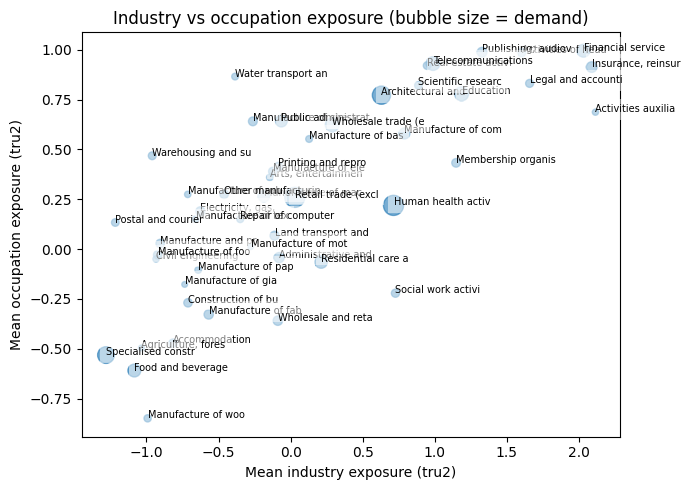

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_ind_vs_occ_exposure_bubble.png
Pearson: 0.7389407993948134
Spearman: 0.7388775510204082
Weighted Pearson: 0.8005239884029244
Demand vs ind exposure Pearson: 0.18374627860609496
Demand vs ind exposure Spearman: 0.32357142857142857
Demand vs ind exposure Weighted Pearson: 0.10154224398132866
Demand vs occ exposure Pearson: 0.09449938433922589
Demand vs occ exposure Spearman: 0.15775510204081633
Demand vs occ exposure Weighted Pearson: 0.0034753956328008526


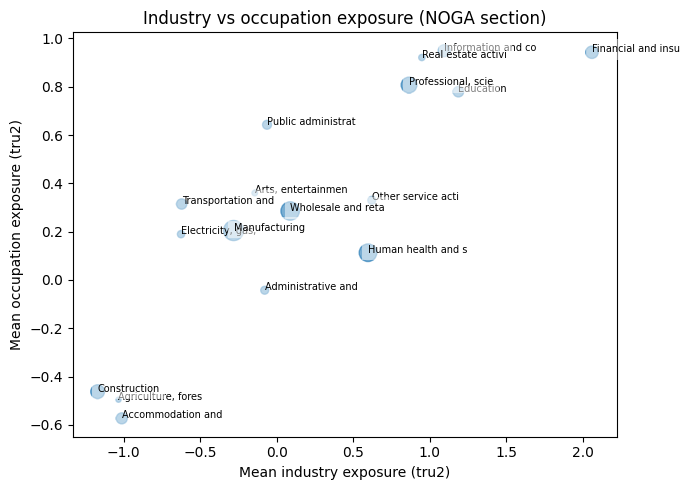

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_ind_vs_occ_exposure_bubble_noga_section.png
noga_section Pearson: 0.8533950670974755
noga_section Spearman: 0.8406862745098039
noga_section Weighted Pearson: 0.844867571648986
noga_section Demand vs ind exposure Pearson: 0.09431413601243581
noga_section Demand vs ind exposure Spearman: 0.18872549019607843
noga_section Demand vs ind exposure Weighted Pearson: -0.12643440831797798
noga_section Demand vs occ exposure Pearson: 0.004620884549593317
noga_section Demand vs occ exposure Spearman: 0.03676470588235294
noga_section Demand vs occ exposure Weighted Pearson: -0.1389746663561954


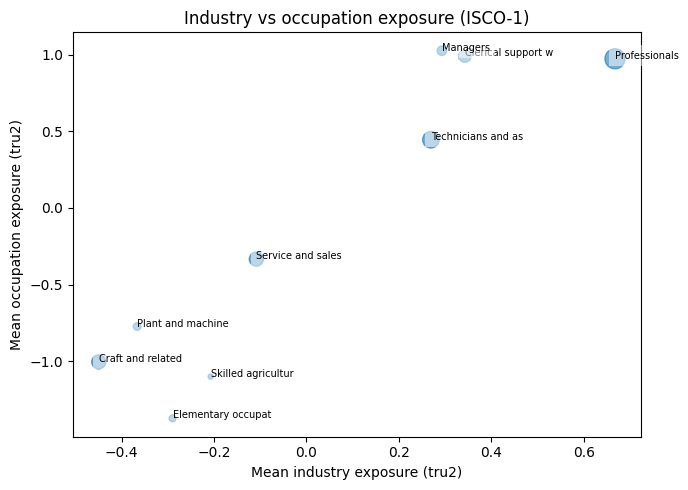

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_ind_vs_occ_exposure_bubble_isco1.png
isco1 Pearson: 0.9233389293078785
isco1 Spearman: 0.8
isco1 Weighted Pearson: 0.9465835516134468
isco1 Demand vs ind exposure Pearson: 0.6523140992123206
isco1 Demand vs ind exposure Spearman: 0.48333333333333334
isco1 Demand vs ind exposure Weighted Pearson: 0.730914332572693
isco1 Demand vs occ exposure Pearson: 0.5593074726592053
isco1 Demand vs occ exposure Spearman: 0.5166666666666667
isco1 Demand vs occ exposure Weighted Pearson: 0.5423773569109774


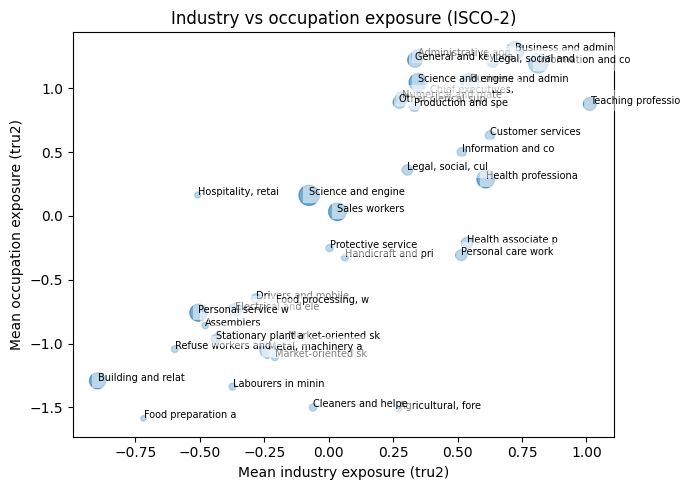

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_ind_vs_occ_exposure_bubble_isco2.png
isco2 Pearson: 0.7686049796011416
isco2 Spearman: 0.7667140825035562
isco2 Weighted Pearson: 0.8342760008179166
isco2 Demand vs ind exposure Pearson: 0.2837231944546775
isco2 Demand vs ind exposure Spearman: 0.422475106685633
isco2 Demand vs ind exposure Weighted Pearson: 0.09512478725530482
isco2 Demand vs occ exposure Pearson: 0.433456234992977
isco2 Demand vs occ exposure Spearman: 0.5410876463508042
isco2 Demand vs occ exposure Weighted Pearson: 0.2241757506558724


In [ ]:
# Industry-level mix
ind_mix = _df.groupby(_df["comp_indu_noga_label"].fillna("Unknown")).apply(
    lambda g: pd.Series({
        "demand_total_tru2": g["srvy_wght_tru2"].sum(),
        "mean_ind_exp": np.average(g[ind_exp_col].dropna(), weights=g.loc[g[ind_exp_col].notna(),"srvy_wght_tru2"]) if g[ind_exp_col].notna().any() else np.nan,
        "mean_occ_exp": np.average(g[occ_exp_col].dropna(), weights=g.loc[g[occ_exp_col].notna(),"srvy_wght_tru2"]) if g[occ_exp_col].notna().any() else np.nan,
        "share_high_occ_p80": (
            g.loc[g[occ_exp_col].notna() & (g[occ_exp_col] >= occ_p80), "srvy_wght_tru2"].sum() /
            g.loc[g[occ_exp_col].notna(), "srvy_wght_tru2"].sum()
        ) if g[occ_exp_col].notna().any() else np.nan,
        "coverage": g.loc[g[occ_exp_col].notna(), "srvy_wght_tru2"].sum() / g["srvy_wght_tru2"].sum() if g["srvy_wght_tru2"].sum() else np.nan,
    })
).reset_index().rename(columns={"comp_indu_noga_label":"indu_label"})

ind_mix.to_csv(OUT_TABLES / "table_ind_occ_mix.csv", index=False)

# Bubble scatter
plt.figure(figsize=(7,5))
ind_mix_plot = _finite_for_plot(ind_mix, "mean_ind_exp", "mean_occ_exp", y_positive=False)
ind_mix_plot = ind_mix_plot[ind_mix_plot["demand_total_tru2"] > 0]
plt.scatter(ind_mix_plot["mean_ind_exp"], ind_mix_plot["mean_occ_exp"], s=(ind_mix_plot["demand_total_tru2"] / ind_mix_plot["demand_total_tru2"].max())*200+10, alpha=0.6)
for _, row in ind_mix_plot.iterrows():
    plt.text(row["mean_ind_exp"], row["mean_occ_exp"], str(row["indu_label"])[:18], fontsize=7,
             bbox=dict(facecolor="white", alpha=0.5, edgecolor="none"))
plt.xlabel("Mean industry exposure (tru2)")
plt.ylabel("Mean occupation exposure (tru2)")
plt.title("Industry vs occupation exposure (bubble size = demand)")
plt.tight_layout()
fig_path = OUT_VIS / "fig_ind_vs_occ_exposure_bubble.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print('Saved', fig_path)

# Correlations (unweighted + weighted)
valid = ind_mix.dropna(subset=["mean_ind_exp", "mean_occ_exp"])
pearson = valid[["mean_ind_exp","mean_occ_exp"]].corr().iloc[0,1]
spearman = valid[["mean_ind_exp","mean_occ_exp"]].corr(method="spearman").iloc[0,1]

w = valid["demand_total_tru2"].to_numpy()
xi = valid["mean_ind_exp"].to_numpy()
yi = valid["mean_occ_exp"].to_numpy()
wmx = np.average(xi, weights=w)
wmy = np.average(yi, weights=w)
wcov = np.average((xi-wmx)*(yi-wmy), weights=w)
wsx = np.sqrt(np.average((xi-wmx)**2, weights=w))
wsy = np.sqrt(np.average((yi-wmy)**2, weights=w))
weighted_pearson = wcov / (wsx*wsy) if wsx>0 and wsy>0 else np.nan

print("Pearson:", pearson)
print("Spearman:", spearman)
print("Weighted Pearson:", weighted_pearson)

# Demand vs exposure correlations (unweighted + weighted)
valid_d = valid.dropna(subset=["demand_total_tru2", "mean_ind_exp", "mean_occ_exp"])
if not valid_d.empty:
    pearson_d_ind = valid_d[["demand_total_tru2","mean_ind_exp"]].corr().iloc[0,1]
    spearman_d_ind = valid_d[["demand_total_tru2","mean_ind_exp"]].corr(method="spearman").iloc[0,1]
    pearson_d_occ = valid_d[["demand_total_tru2","mean_occ_exp"]].corr().iloc[0,1]
    spearman_d_occ = valid_d[["demand_total_tru2","mean_occ_exp"]].corr(method="spearman").iloc[0,1]

    w_d = valid_d["demand_total_tru2"].to_numpy()
    xd = valid_d["demand_total_tru2"].to_numpy()
    yi = valid_d["mean_ind_exp"].to_numpy()
    yo = valid_d["mean_occ_exp"].to_numpy()
    wmx = (xd * w_d).sum() / w_d.sum()
    wmy_i = (yi * w_d).sum() / w_d.sum()
    wmy_o = (yo * w_d).sum() / w_d.sum()
    wcov_i = (w_d * (xd - wmx) * (yi - wmy_i)).sum() / w_d.sum()
    wcov_o = (w_d * (xd - wmx) * (yo - wmy_o)).sum() / w_d.sum()
    wsx = ((w_d * (xd - wmx) ** 2).sum() / w_d.sum()) ** 0.5
    wsy_i = ((w_d * (yi - wmy_i) ** 2).sum() / w_d.sum()) ** 0.5
    wsy_o = ((w_d * (yo - wmy_o) ** 2).sum() / w_d.sum()) ** 0.5
    weighted_pearson_d_ind = wcov_i / (wsx * wsy_i) if wsx>0 and wsy_i>0 else np.nan
    weighted_pearson_d_occ = wcov_o / (wsx * wsy_o) if wsx>0 and wsy_o>0 else np.nan

    print("Demand vs ind exposure Pearson:", pearson_d_ind)
    print("Demand vs ind exposure Spearman:", spearman_d_ind)
    print("Demand vs ind exposure Weighted Pearson:", weighted_pearson_d_ind)
    print("Demand vs occ exposure Pearson:", pearson_d_occ)
    print("Demand vs occ exposure Spearman:", spearman_d_occ)
    print("Demand vs occ exposure Weighted Pearson:", weighted_pearson_d_occ)

# === Industry-level mix: NOGA section + ISCO-1/2 ===

def industry_mix_by(group_label_col, exp_col, out_suffix, title):
    if group_label_col not in _df.columns:
        print(f"Skipping {out_suffix}: {group_label_col} not in dataset")
        return
    mix = _df.groupby(_df[group_label_col].fillna("Unknown")).apply(
        lambda g: pd.Series({
            "demand_total_tru2": g["srvy_wght_tru2"].sum(),
            "mean_ind_exp": np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(),"srvy_wght_tru2"]) if g[exp_col].notna().any() else np.nan,
            "mean_occ_exp": np.average(g[occ_exp_col].dropna(), weights=g.loc[g[occ_exp_col].notna(),"srvy_wght_tru2"]) if g[occ_exp_col].notna().any() else np.nan,
            "share_high_occ_p80": (
                g.loc[g[occ_exp_col].notna() & (g[occ_exp_col] >= occ_p80), "srvy_wght_tru2"].sum() /
                g.loc[g[occ_exp_col].notna(), "srvy_wght_tru2"].sum()
            ) if g[occ_exp_col].notna().any() else np.nan,
            "coverage": g.loc[g[occ_exp_col].notna(), "srvy_wght_tru2"].sum() / g["srvy_wght_tru2"].sum() if g["srvy_wght_tru2"].sum() else np.nan,
        })
    ).reset_index().rename(columns={group_label_col: "indu_label"})

    mix.to_csv(OUT_TABLES / f"table_ind_occ_mix_{out_suffix}.csv", index=False)

    plt.figure(figsize=(7,5))
    mix_plot = _finite_for_plot(mix, "mean_ind_exp", "mean_occ_exp", y_positive=False)
    mix_plot = mix_plot[mix_plot["demand_total_tru2"] > 0]
    plt.scatter(mix_plot["mean_ind_exp"], mix_plot["mean_occ_exp"],
                s=(mix_plot["demand_total_tru2"] / mix_plot["demand_total_tru2"].max())*200+10,
                alpha=0.6)
    for _, row in mix_plot.iterrows():
        plt.text(row["mean_ind_exp"], row["mean_occ_exp"], str(row["indu_label"])[:18], fontsize=7,
                 bbox=dict(facecolor="white", alpha=0.5, edgecolor="none"))
    plt.xlabel("Mean industry exposure (tru2)")
    plt.ylabel("Mean occupation exposure (tru2)")
    plt.title(title)
    plt.tight_layout()
    fig_path = OUT_VIS / f"fig_ind_vs_occ_exposure_bubble_{out_suffix}.png"
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print("Saved", fig_path)

    valid = mix.dropna(subset=["mean_ind_exp", "mean_occ_exp"])
    pearson = valid[["mean_ind_exp","mean_occ_exp"]].corr().iloc[0,1]
    spearman = valid[["mean_ind_exp","mean_occ_exp"]].corr(method="spearman").iloc[0,1]
    w = valid["demand_total_tru2"].to_numpy()
    xi = valid["mean_ind_exp"].to_numpy()
    yi = valid["mean_occ_exp"].to_numpy()
    wmx = np.average(xi, weights=w)
    wmy = np.average(yi, weights=w)
    wcov = np.average((xi-wmx)*(yi-wmy), weights=w)
    wsx = np.sqrt(np.average((xi-wmx)**2, weights=w))
    wsy = np.sqrt(np.average((yi-wmy)**2, weights=w))
    weighted_pearson = wcov / (wsx*wsy) if wsx>0 and wsy>0 else np.nan

    print(f"{out_suffix} Pearson:", pearson)
    print(f"{out_suffix} Spearman:", spearman)
    print(f"{out_suffix} Weighted Pearson:", weighted_pearson)

    valid_d = valid.dropna(subset=["demand_total_tru2", "mean_ind_exp", "mean_occ_exp"])
    if not valid_d.empty:
        pearson_d_ind = valid_d[["demand_total_tru2","mean_ind_exp"]].corr().iloc[0,1]
        spearman_d_ind = valid_d[["demand_total_tru2","mean_ind_exp"]].corr(method="spearman").iloc[0,1]
        pearson_d_occ = valid_d[["demand_total_tru2","mean_occ_exp"]].corr().iloc[0,1]
        spearman_d_occ = valid_d[["demand_total_tru2","mean_occ_exp"]].corr(method="spearman").iloc[0,1]

        w_d = valid_d["demand_total_tru2"].to_numpy()
        xd = valid_d["demand_total_tru2"].to_numpy()
        yi = valid_d["mean_ind_exp"].to_numpy()
        yo = valid_d["mean_occ_exp"].to_numpy()
        wmx = (xd * w_d).sum() / w_d.sum()
        wmy_i = (yi * w_d).sum() / w_d.sum()
        wmy_o = (yo * w_d).sum() / w_d.sum()
        wcov_i = (w_d * (xd - wmx) * (yi - wmy_i)).sum() / w_d.sum()
        wcov_o = (w_d * (xd - wmx) * (yo - wmy_o)).sum() / w_d.sum()
        wsx = ((w_d * (xd - wmx) ** 2).sum() / w_d.sum()) ** 0.5
        wsy_i = ((w_d * (yi - wmy_i) ** 2).sum() / w_d.sum()) ** 0.5
        wsy_o = ((w_d * (yo - wmy_o) ** 2).sum() / w_d.sum()) ** 0.5
        weighted_pearson_d_ind = wcov_i / (wsx * wsy_i) if wsx>0 and wsy_i>0 else np.nan
        weighted_pearson_d_occ = wcov_o / (wsx * wsy_o) if wsx>0 and wsy_o>0 else np.nan

        print(f"{out_suffix} Demand vs ind exposure Pearson:", pearson_d_ind)
        print(f"{out_suffix} Demand vs ind exposure Spearman:", spearman_d_ind)
        print(f"{out_suffix} Demand vs ind exposure Weighted Pearson:", weighted_pearson_d_ind)
        print(f"{out_suffix} Demand vs occ exposure Pearson:", pearson_d_occ)
        print(f"{out_suffix} Demand vs occ exposure Spearman:", spearman_d_occ)
        print(f"{out_suffix} Demand vs occ exposure Weighted Pearson:", weighted_pearson_d_occ)

noga_label_col = "industry_section_label" if "industry_section_label" in _df.columns else "noga_section_label"
industry_mix_by(noga_label_col, ind_exp_col, "noga_section", "Industry vs occupation exposure (NOGA section)")
industry_mix_by("occu_isco1_label", ind_exp_col, "isco1", "Industry vs occupation exposure (ISCO-1)")
industry_mix_by("occu_isco2_label", ind_exp_col, "isco2", "Industry vs occupation exposure (ISCO-2)")


## 7) Avg demand per posting by exposure decile

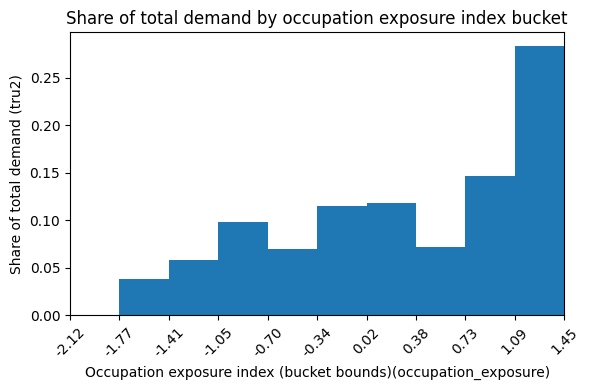

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_share_total_demand_by_exposure_bucket_tru2.png


In [22]:
# Ensure bucket_demand exists (recompute if this cell runs standalone)
if "bucket_demand" not in globals():
    exposure_col = "occupation_exposure"
    occ_nonmiss = _df[_df[exposure_col].notna()].copy()
    num_buckets = 10
    min_exp = occ_nonmiss[exposure_col].min()
    max_exp = occ_nonmiss[exposure_col].max()
    bucket_edges = np.linspace(min_exp, max_exp, num_buckets + 1)
    occ_nonmiss["occ_exp_bucket"] = pd.cut(
        occ_nonmiss[exposure_col],
        bins=bucket_edges,
        labels=False,
        include_lowest=True
    )
    bucket_demand = (
        occ_nonmiss.groupby("occ_exp_bucket")
        .agg(demand_tru2=("srvy_wght_tru2", "sum"))
        .reset_index()
    )

# Share of total demand by exposure bucket (histogram on bucket bounds)

bucket_total_tru2 = bucket_demand["demand_tru2"].sum()

# Ensure all buckets present (fill missing with 0)
all_buckets = pd.DataFrame({"occ_exp_bucket": range(len(bucket_edges)-1)})
bucket_full = all_buckets.merge(bucket_demand, on="occ_exp_bucket", how="left").fillna({"demand_tru2": 0})
bucket_full["share_of_tru2"] = bucket_full["demand_tru2"] / bucket_total_tru2 if bucket_total_tru2 else 0

left_edges = bucket_edges[:-1]
widths = np.diff(bucket_edges)

plt.figure(figsize=(6,4))
plt.bar(left_edges, bucket_full["share_of_tru2"], width=widths, align='edge')
plt.xlabel(f"Occupation exposure index (bucket bounds)({exposure_col})")
plt.ylabel("Share of total demand (tru2)")
plt.title("Share of total demand by occupation exposure index bucket")
plt.xlim(bucket_edges[0], bucket_edges[-1])
plt.xticks(bucket_edges, [f"{e:.2f}" for e in bucket_edges], rotation=45)
plt.tight_layout()
fig_path4b = OUT_VIS / "fig_share_total_demand_by_exposure_bucket_tru2.png"
plt.savefig(fig_path4b, dpi=150)
plt.show()
print("Saved", fig_path4b)


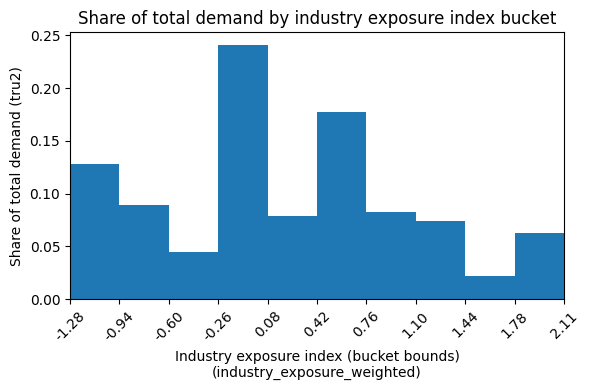

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_share_total_demand_by_industry_exposure_bucket_tru2.png


In [23]:
# Industry exposure: share of total demand by exposure bucket (histogram on bucket bounds)

ind_col = ind_exp_col
ind_nonmiss = _df[_df[ind_col].notna()].copy()
if ind_nonmiss.empty:
    print("No non-missing industry exposure values found for histogram.")
else:
    num_buckets_ind = 10
    ind_min = ind_nonmiss[ind_col].min()
    ind_max = ind_nonmiss[ind_col].max()
    ind_edges = np.linspace(ind_min, ind_max, num_buckets_ind + 1)

    ind_nonmiss["ind_exp_bucket"] = pd.cut(
        ind_nonmiss[ind_col],
        bins=ind_edges,
        labels=False,
        include_lowest=True
    )

    ind_bucket_demand = (
        ind_nonmiss.groupby("ind_exp_bucket")
        .agg(demand_tru2=("srvy_wght_tru2", "sum"))
        .reset_index()
    )

    ind_total_tru2 = ind_bucket_demand["demand_tru2"].sum()
    all_buckets_ind = pd.DataFrame({"ind_exp_bucket": range(len(ind_edges)-1)})
    ind_bucket_full = all_buckets_ind.merge(ind_bucket_demand, on="ind_exp_bucket", how="left").fillna({"demand_tru2": 0})
    ind_bucket_full["share_of_tru2"] = ind_bucket_full["demand_tru2"] / ind_total_tru2 if ind_total_tru2 else 0

    ind_left_edges = ind_edges[:-1]
    ind_widths = np.diff(ind_edges)

    plt.figure(figsize=(6,4))
    plt.bar(ind_left_edges, ind_bucket_full["share_of_tru2"], width=ind_widths, align='edge')
    plt.xlabel(f"Industry exposure index (bucket bounds)\n({ind_col})")
    plt.ylabel("Share of total demand (tru2)")
    plt.title("Share of total demand by industry exposure index bucket")
    plt.xlim(ind_edges[0], ind_edges[-1])
    plt.xticks(ind_edges, [f"{e:.2f}" for e in ind_edges], rotation=45)
    plt.tight_layout()
    fig_path_ind = OUT_VIS / "fig_share_total_demand_by_industry_exposure_bucket_tru2.png"
    plt.savefig(fig_path_ind, dpi=150)
    plt.show()
    print("Saved", fig_path_ind)


## 7) Exposure vs Other fields

/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/2915315604.py:80: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,class,weighted_share_pct
2,small,22.491997
1,medium/unknown,48.443895
0,large,29.064108


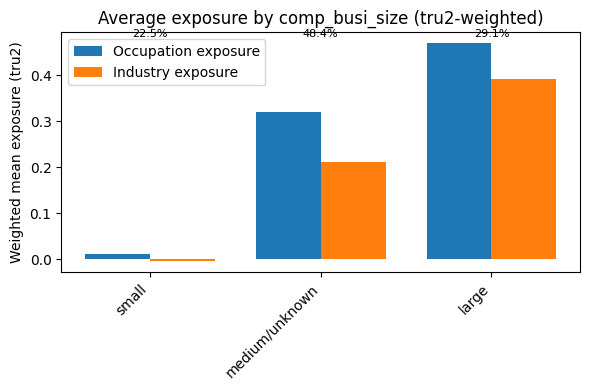

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_exposure_by_comp_busi_size.png


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/2915315604.py:80: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,class,weighted_share_pct
0,no,87.655952
1,yes,12.344048


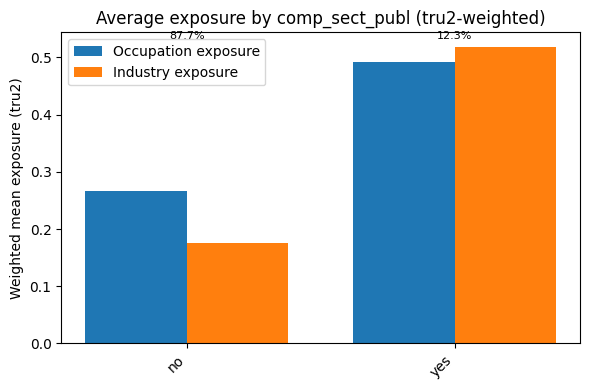

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_exposure_by_comp_sect_publ.png


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/2915315604.py:80: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,class,weighted_share_pct
1,not recorded for jobs no. 5-10,0.584560
0,no,85.079566
2,yes,14.335874


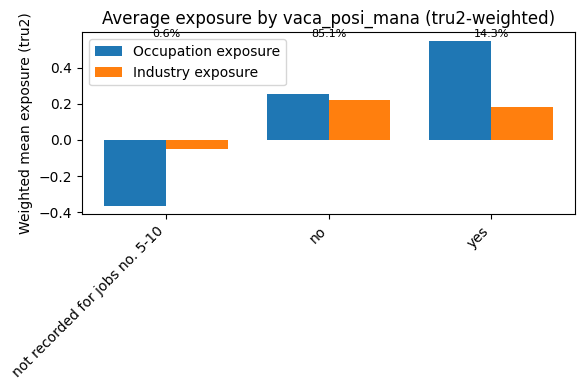

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_exposure_by_vaca_posi_mana.png


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/2915315604.py:80: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,class,weighted_share_pct
2,not recorded for jobs no. 5-10,0.584560
0,low/not specified,89.785393
1,medium/high,9.630047


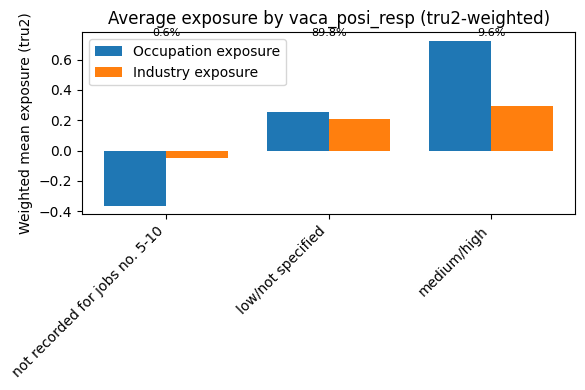

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_exposure_by_vaca_posi_resp.png


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/2915315604.py:80: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,class,weighted_share_pct
3,not recorded for jobs no. 5-10,0.584560
1,male,11.055841
2,neutral,85.594036
0,female,2.765562


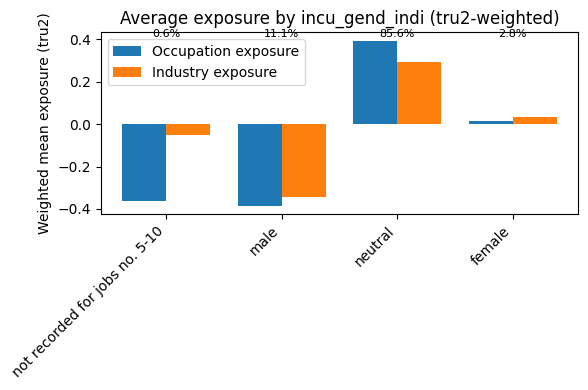

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_exposure_by_incu_gend_indi.png


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/2915315604.py:148: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: _mean_exposure(g, exp_col))


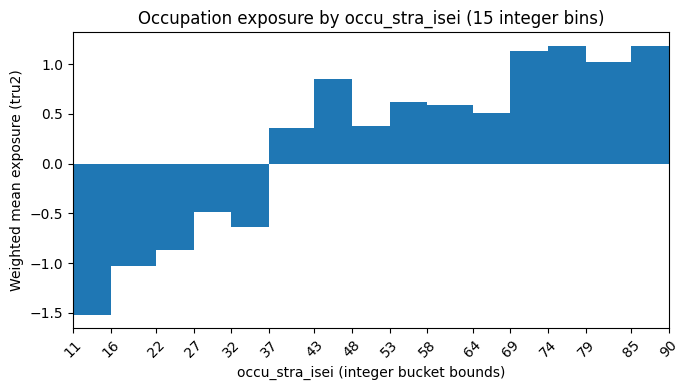

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_mean_occupation_exposure_by_occu_stra_isei_bins.png


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/2915315604.py:148: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: _mean_exposure(g, exp_col))


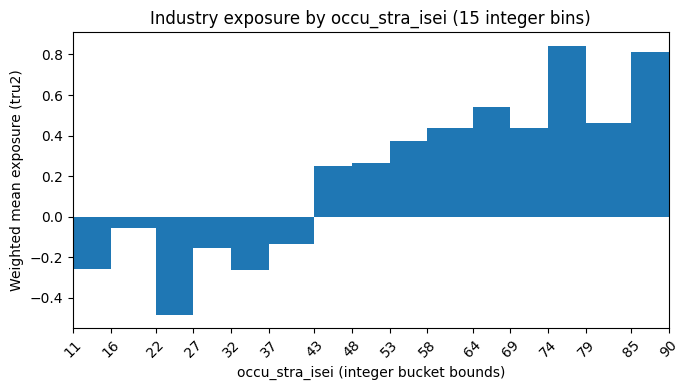

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_mean_industry_exposure_weighted_by_occu_stra_isei_bins.png


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/2915315604.py:148: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: _mean_exposure(g, exp_col))


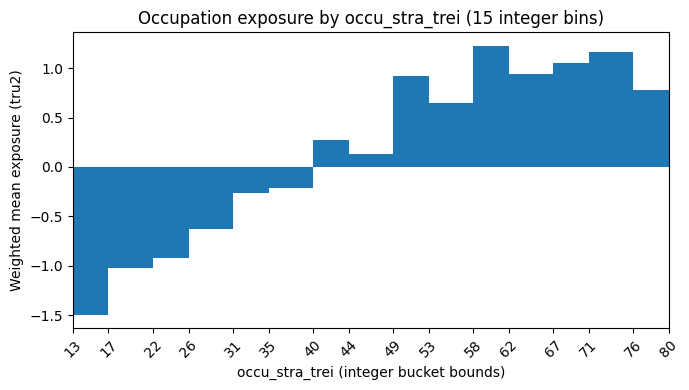

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_mean_occupation_exposure_by_occu_stra_trei_bins.png


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/2915315604.py:148: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: _mean_exposure(g, exp_col))


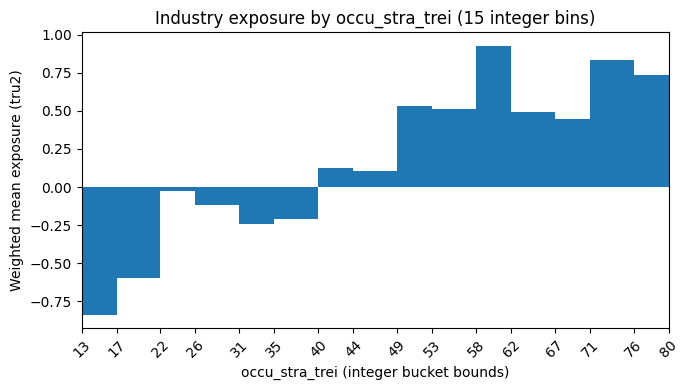

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_mean_industry_exposure_weighted_by_occu_stra_trei_bins.png


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/2915315604.py:148: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: _mean_exposure(g, exp_col))


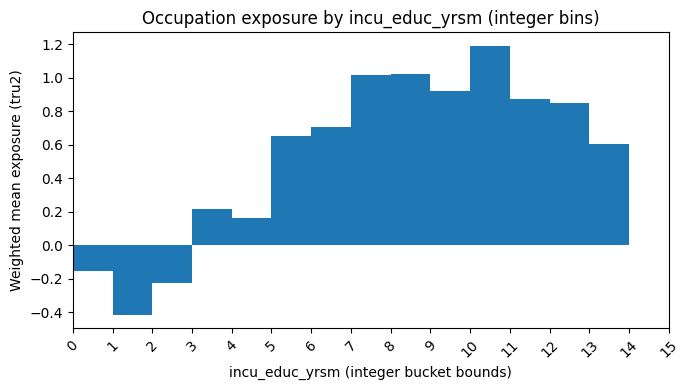

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_mean_occupation_exposure_by_incu_educ_yrsm_bins.png


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_2328/2915315604.py:148: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: _mean_exposure(g, exp_col))


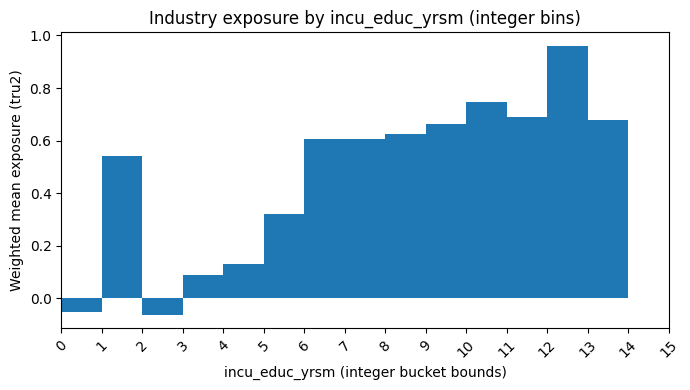

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_mean_industry_exposure_weighted_by_incu_educ_yrsm_bins.png


In [24]:
# === Exposure by other fields (class bars + integer-bin exposure histograms) ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re

df = _df.copy()
occ_exp_col = 'occupation_exposure'
ind_exp_col = 'industry_exposure_weighted'

def _wmean(series, weights):
    if series.empty:
        return np.nan
    return np.average(series, weights=weights)

def _mean_exposure(g, exp_col):
    m = g[exp_col].notna()
    if not m.any():
        return np.nan
    return _wmean(g.loc[m, exp_col], g.loc[m, 'srvy_wght_tru2'])

def _load_codebook_labels(var_name):
    # Parse labels from Final dataset field descriptions.md
    ROOT = Path.cwd().resolve()
    for p in [ROOT] + list(ROOT.parents):
        md_path = p / 'scripts' / 'Analysis' / 'Final dataset field descriptions.md'
        if md_path.exists():
            text = md_path.read_text(encoding='utf-8')
            break
    else:
        return {}
    pat = re.compile(rf"### `{re.escape(var_name)}`(.*?)^### `", re.S | re.M)
    m = pat.search(text)
    if not m:
        return {}
    section = m.group(1)
    label_pat = re.compile(r"- `([^`]+)` =\s*([^\n]+)")
    rows = []
    for code_raw, label in label_pat.findall(section):
        code_raw = code_raw.strip()
        if code_raw.upper() == 'NA':
            mcode = re.match(r"(-?\d+)\s*(.*)", label.strip())
            if not mcode:
                continue
            code = int(mcode.group(1))
            label_text = mcode.group(2).strip()
        else:
            try:
                code = int(code_raw)
            except ValueError:
                continue
            label_text = label.strip()
            mlabel = re.match(r"\d+\s*(.*)", label_text)
            if mlabel:
                label_text = mlabel.group(1).strip()
        rows.append((code, label_text))
    if not rows:
        return {}
    out = {}
    for code, label in rows:
        out[code] = label
    return out

def plot_avg_exposure_by_class(col, title):
    if col not in df.columns:
        print(f'Skip {col}: not in dataset')
        return
    tmp = df[df[col].notna()].copy()
    if tmp.empty:
        print(f'Skip {col}: all missing')
        return
    # map labels
    label_map = _load_codebook_labels(col)
    tmp['_code'] = pd.to_numeric(tmp[col], errors='coerce')
    tmp['_label'] = tmp['_code'].map(label_map).fillna('Unknown')

    res = (
        tmp.groupby('_label', observed=True)
           .apply(lambda g: pd.Series({
               'mean_occ_exp': _mean_exposure(g, occ_exp_col),
               'mean_ind_exp': _mean_exposure(g, ind_exp_col),
               'demand_tru2': g['srvy_wght_tru2'].sum(),
               'n': len(g)
           }))
           .reset_index()
           .rename(columns={'_label': 'class'})
    )
    total = res['demand_tru2'].sum()
    res['weighted_share_pct'] = res['demand_tru2'] / total * 100 if total else 0

    # sort by code order if possible
    try:
        res['_code_num'] = res['class'].map({v:k for k,v in label_map.items()}).astype(float)
        res = res.sort_values(['_code_num', 'class'])
    except Exception:
        res = res.sort_values('class')

    display(res[['class','weighted_share_pct']])

    x = np.arange(len(res))
    width = 0.38
    fig_w = max(6, len(res) * 0.5)
    plt.figure(figsize=(fig_w, 4))
    plt.bar(x - width/2, res['mean_occ_exp'], width, label='Occupation exposure')
    plt.bar(x + width/2, res['mean_ind_exp'], width, label='Industry exposure')
    plt.xticks(x, res['class'], rotation=45, ha='right')
    plt.ylabel('Weighted mean exposure (tru2)')
    plt.title(title)
    plt.legend()
    # annotate weighted share
    ymax = np.nanmax([res['mean_occ_exp'].max(), res['mean_ind_exp'].max()])
    for xi, pct in zip(x, res['weighted_share_pct']):
        plt.text(xi, ymax*1.02 if ymax>0 else 0.01, f"{pct:.1f}%", ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    fig_path = OUT_VIS / f'fig_exposure_by_{col}.png'
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print('Saved', fig_path)

def _integer_edges(min_int, max_int, bins=None):
    if bins is None:
        return np.arange(min_int, max_int + 2)
    # try to build bins+1 integer edges
    edges = np.linspace(min_int, max_int + 1, bins + 1)
    edges = np.unique(np.round(edges).astype(int))
    if len(edges) < 2:
        return np.arange(min_int, max_int + 2)
    return edges

def plot_mean_exposure_by_integer_bins(col, exp_col, title, bins=None):
    if col not in df.columns:
        print(f'Skip {col}: not in dataset')
        return
    tmp = df.copy()
    tmp[col] = pd.to_numeric(tmp[col], errors='coerce')
    tmp = tmp[tmp[col].notna()]
    tmp = tmp[tmp[exp_col].notna()]
    if tmp.empty:
        print(f'Skip {col} ({exp_col}): no valid rows')
        return
    min_int = int(np.floor(tmp[col].min()))
    max_int = int(np.ceil(tmp[col].max()))
    edges = _integer_edges(min_int, max_int, bins=bins)
    tmp['bin'] = pd.cut(tmp[col], bins=edges, include_lowest=True, right=False)
    bucket = (
        tmp.groupby('bin', observed=True)
           .apply(lambda g: _mean_exposure(g, exp_col))
           .reset_index(name='mean_exp')
    )
    all_bins = pd.DataFrame({'bin': pd.cut(edges[:-1], bins=edges, include_lowest=True, right=False)})
    bucket = all_bins.merge(bucket, on='bin', how='left').fillna({'mean_exp':0})
    left_edges = edges[:-1]
    widths = np.diff(edges)

    plt.figure(figsize=(7,4))
    plt.bar(left_edges, bucket['mean_exp'], width=widths, align='edge')
    plt.xlabel(f'{col} (integer bucket bounds)')
    plt.ylabel(f'Weighted mean exposure (tru2)')
    plt.title(title)
    plt.xlim(edges[0], edges[-1])
    plt.xticks(edges, rotation=45)
    plt.tight_layout()
    fig_path = OUT_VIS / f'fig_mean_{exp_col}_by_{col}_bins.png'
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print('Saved', fig_path)

# Bar charts by class (labeled, no IDs in labels)
for col in ['comp_busi_size', 'comp_sect_publ', 'vaca_posi_mana', 'vaca_posi_resp', 'incu_gend_indi']:
    plot_avg_exposure_by_class(col, f'Average exposure by {col} (tru2-weighted)')

# Integer-bucket mean exposure histograms (two per variable)
# 15 bins for occu_stra_isei and occu_stra_trei
plot_mean_exposure_by_integer_bins('occu_stra_isei', occ_exp_col, 'Occupation exposure by occu_stra_isei (15 integer bins)', bins=15)
plot_mean_exposure_by_integer_bins('occu_stra_isei', ind_exp_col, 'Industry exposure by occu_stra_isei (15 integer bins)', bins=15)

plot_mean_exposure_by_integer_bins('occu_stra_trei', occ_exp_col, 'Occupation exposure by occu_stra_trei (15 integer bins)', bins=15)
plot_mean_exposure_by_integer_bins('occu_stra_trei', ind_exp_col, 'Industry exposure by occu_stra_trei (15 integer bins)', bins=15)

# incu_educ_yrsm uses integer buckets (one per integer)
plot_mean_exposure_by_integer_bins('incu_educ_yrsm', occ_exp_col, 'Occupation exposure by incu_educ_yrsm (integer bins)', bins=None)
plot_mean_exposure_by_integer_bins('incu_educ_yrsm', ind_exp_col, 'Industry exposure by incu_educ_yrsm (integer bins)', bins=None)


Weighted median occ exposure: 0.4360305666666666


,bucket,group,mean_educ_yrs,share
0,2010-2014,Bottom 50%,2.940650,0.452688
1,2010-2014,Top 50%,4.988569,0.547312
2,2015-2019,Bottom 50%,3.188413,0.452163
3,2015-2019,Top 50%,5.244039,0.547837
4,2020-2024,Bottom 50%,3.320474,0.495727
5,2020-2024,Top 50%,5.249035,0.504273


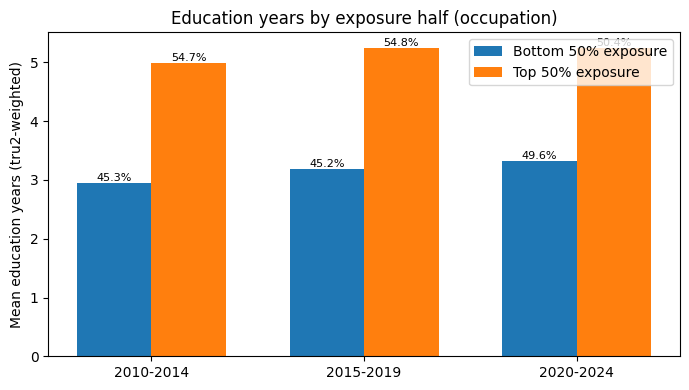

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1/visuals/fig_educ_years_by_occ_exposure_halves.png


In [25]:
# === Education years by exposure half (occupation) across year buckets ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = _df.copy()
occ_exp_col = 'occupation_exposure'
educ_col = 'incu_educ_yrsm'

# weighted median (tru2) for occupation exposure
def weighted_quantile(values, weights, q):
    v = pd.to_numeric(values, errors='coerce').to_numpy(dtype=float)
    w = pd.to_numeric(weights, errors='coerce').to_numpy(dtype=float)
    mask = ~np.isnan(v) & ~np.isnan(w)
    if mask.sum() == 0:
        return np.nan
    v = v[mask]
    w = w[mask]
    order = np.argsort(v)
    v = v[order]
    w = w[order]
    cum = np.cumsum(w)
    total = cum[-1]
    return v[np.searchsorted(cum, q * total)]

median_occ = weighted_quantile(df[occ_exp_col], df['srvy_wght_tru2'], 0.5)
print('Weighted median occ exposure:', median_occ)

def wmean(series, weights):
    if series.empty:
        return np.nan
    return np.average(series, weights=weights)

# Year buckets
bins = [(2010, 2014), (2015, 2019), (2020, 2024)]
rows = []
for start, end in bins:
    sub = df[(df['adve_time_year'] >= start) & (df['adve_time_year'] <= end)].copy()
    sub[educ_col] = pd.to_numeric(sub[educ_col], errors='coerce')
    # bottom / top halves (known exposure + known education)
    low = sub[(sub[occ_exp_col].notna()) & (sub[occ_exp_col] < median_occ) & (sub[educ_col].notna())]
    high = sub[(sub[occ_exp_col].notna()) & (sub[occ_exp_col] >= median_occ) & (sub[educ_col].notna())]
    low_mean = wmean(low[educ_col], low['srvy_wght_tru2'])
    high_mean = wmean(high[educ_col], high['srvy_wght_tru2'])

    # shares within bucket (tru2, known exposure+education only)
    low_w = low['srvy_wght_tru2'].sum()
    high_w = high['srvy_wght_tru2'].sum()
    tot = low_w + high_w
    low_share = low_w / tot if tot else np.nan
    high_share = high_w / tot if tot else np.nan

    rows.append({'bucket': f'{start}-{end}', 'group': 'Bottom 50%', 'mean_educ_yrs': low_mean, 'share': low_share})
    rows.append({'bucket': f'{start}-{end}', 'group': 'Top 50%', 'mean_educ_yrs': high_mean, 'share': high_share})

out = pd.DataFrame(rows)
display(out)

# Plot grouped bars
pivot = out.pivot(index='bucket', columns='group', values='mean_educ_yrs')
share_pivot = out.pivot(index='bucket', columns='group', values='share')

x = np.arange(len(pivot.index))
width = 0.35
plt.figure(figsize=(7,4))
bar1 = plt.bar(x - width/2, pivot['Bottom 50%'], width, label='Bottom 50% exposure')
bar2 = plt.bar(x + width/2, pivot['Top 50%'], width, label='Top 50% exposure')
plt.xticks(x, pivot.index)
plt.ylabel('Mean education years (tru2-weighted)')
plt.title('Education years by exposure half (occupation)')
plt.legend()

# add percentage labels on bars
for bars, grp in [(bar1, 'Bottom 50%'), (bar2, 'Top 50%')]:
    for i, b in enumerate(bars):
        share = share_pivot.loc[pivot.index[i], grp]
        if pd.isna(share):
            continue
        plt.text(b.get_x() + b.get_width()/2, b.get_height(), f"{share:.1%}",
                 ha='center', va='bottom', fontsize=8)

plt.tight_layout()
fig_path = OUT_VIS / 'fig_educ_years_by_occ_exposure_halves.png'
plt.savefig(fig_path, dpi=150)
plt.show()
print('Saved', fig_path)
